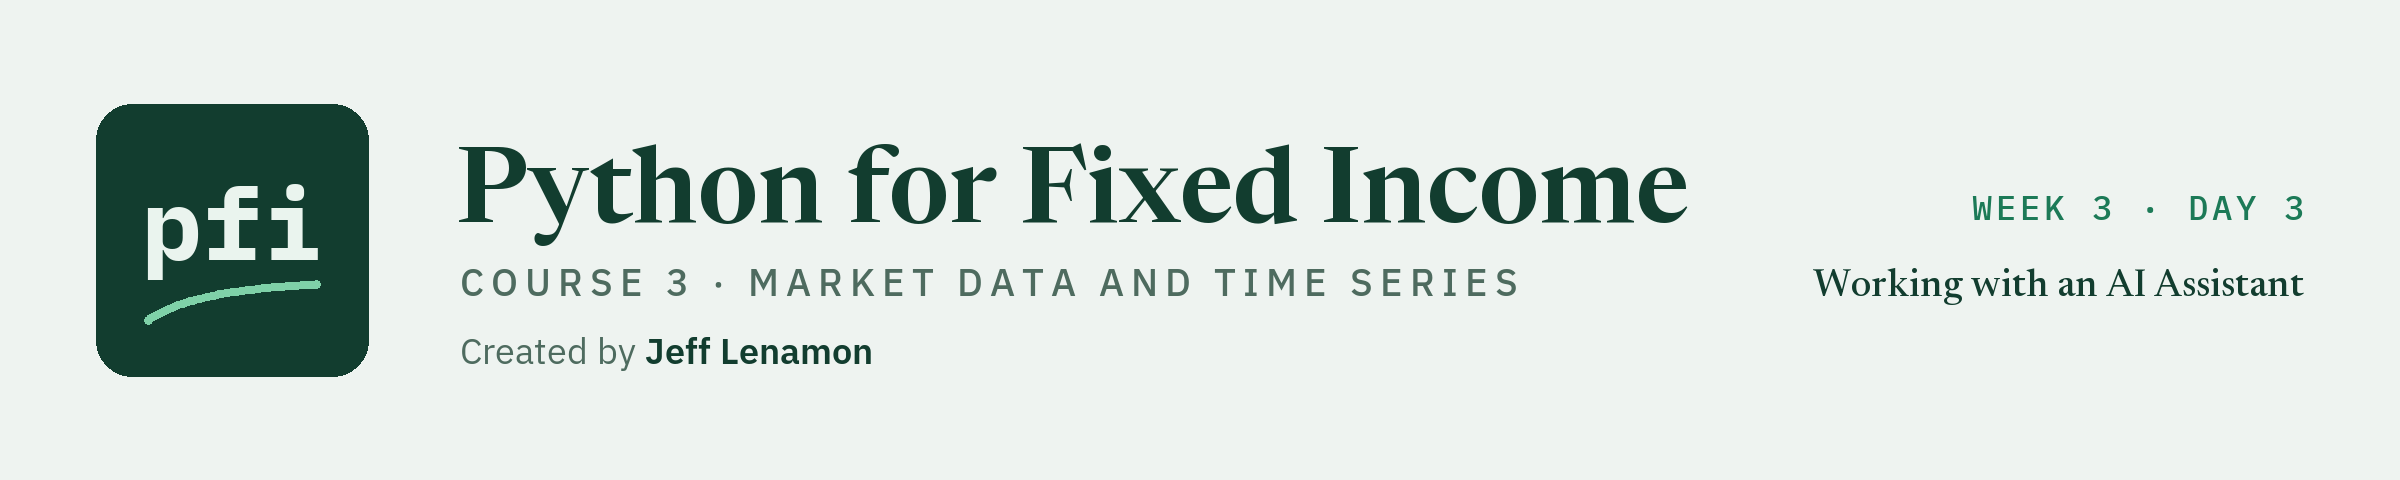

# Working with an AI Assistant

Week 3, Day 3. Assistants write a lot of data code. Today: how to ask for it with a specification you write, how to test what comes back against your own modules and Excel, how to debug with an assistant without pasting anything you must not, how to spot a package that does not exist, and how to ask for JSON and check it.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course3_market_data/week3/day3/13_working_with_an_ai_assistant.ipynb)

Day 11 said assistants write a great deal of SQL, and day 12 showed a join an assistant got wrong. That is true of all data code: ask an AI assistant for a pandas line, a chart, or a bond function and an answer comes back in seconds. It usually runs. Whether it is **right** is your job, and this course has given you the tools for it: docstrings that state units and conventions, your own tested `bondmath` and `marketdata`, Excel reference values, and pytest.

Today you will:

1. Write a prompt as a specification: a docstring, the conventions that apply, and a test.
2. Review three pandas answers by running each against a test.
3. Check an assistant's chart against the numbers behind it.
4. Test an assistant's DV01 function against your own `bondmath` and Excel.
5. Debug with an assistant: what to paste, and what never to paste.
6. Spot a package that does not exist, and check a name before installing anything.
7. Ask for JSON, and check the reply with `parse_json_reply`, the last new function of the course.

**No AI tool is used today.** Every "assistant answer" in this notebook was **written for this course in the style of an AI assistant's answer**, and each one is labelled that way. The notebook needs no AI tool, no account, no key, and no network. No tool or vendor is named or recommended: the habits are the same whichever assistant you use, or are allowed to use.

**What never goes into an AI tool, or into Colab.** This is a rule, not a preference:

| Never paste or upload | Why |
| --- | --- |
| Client names, accounts, or anything that identifies a client | Not yours to share |
| Positions, holdings, trades, or orders from a real book | Not yours to share |
| Anything from an employer: code, data, screenshots, file paths, system names | Not yours to share |
| Credentials: an API key, a password, a token | Whoever holds it can act as you (day 1) |
| A URL or an error message with a key in it | The key travels with it (section 13.5) |

**Your firm's policy comes first.** It decides whether you may use an assistant at work at all, which one, and on what. Everything in this course uses public or synthetic data, so it can be practised anywhere, Colab included.

Q. Set up today's work folder, copy in the data files, and write the start-of-day modules.

In [1]:
# today's setup: modules, the course data, a fresh work folder, and the constants the live cells use
import importlib
import os
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

import pandas as pd

# three packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("pytest", "pytest"), ("requests", "requests"), ("dotenv", "python-dotenv")]:
    try:
        importlib.import_module(module_name)
    except ImportError:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.") from None
import pytest
import requests

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "treasury_par_yields.csv").exists()
data_folder = RAW_DATA if on_github else str(local_data) + os.sep

# 2. your own key file: in your my_bondmath folder, outside every repository. Its path is never printed.
ENV_FILE = Path.home() / "projects" / "my_bondmath" / ".env"

# 3. the two constants of the live cells
NO_KEY_MESSAGE = "Live cell skipped: no FRED key was found. Every other cell runs without one."
# ICE BofA and Moody's values stay off the screen unless you set this to True, on your own machine only
SHOW_LICENSED_VALUES = False

# 4. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course3_13_"))
os.chdir(work)

# 5. copy today's data files into the work folder
DATA_FILES = ["treasury_par_yields.csv", "course3_synthetic_spreads.csv", "course3_excel_reference.csv", "bondmath_excel_reference.csv", "course3_fred_format_dgs10.json", "holdings.csv", "ratings.csv", "trade_blotter.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES) or 'none'}")
print(f"pytest {pytest.__version__}, requests {requests.__version__}")

Work folder: pfi_course3_13_h8zykdyb, in your temp folder
Data files from the data folder of the course repo: treasury_par_yields.csv, course3_synthetic_spreads.csv, course3_excel_reference.csv, bondmath_excel_reference.csv, course3_fred_format_dgs10.json, holdings.csv, ratings.csv, trade_blotter.csv
pytest 9.1.1, requests 2.34.2


Q. Write `bondmath.py`, the reference copy of the module you finished in Course 2.

It is written into the work folder so that every notebook runs, in Colab too, whether or not you took Course 2. To use your own copy instead, run this line in a new cell after the next one:

```python
shutil.copy(Path.home() / "projects" / "my_bondmath" / "bondmath.py", work)
```

The saved outputs of this notebook always come from the reference copy.

In [2]:
%%writefile bondmath.py
"""bondmath: bond math for fixed-rate bullet bonds, checked against Excel.

Written day by day in Python for Fixed Income, Course 2: Bond Math.

Units, the same in every function:
- coupon_pct and yield_pct are annual rates in percent: 7.0 means 7 percent. Excel takes decimals (0.07).
- Prices and accrued interest are per 100 of face.
- Durations are in years, convexity in years squared, spreads in basis points.
- frequency is the number of coupons (or compounding periods) a year: 1, 2, or 4.
- basis is the day count: "30/360" (Excel basis 0) or "ACT/ACT" (Excel basis 1).
- Dates are datetime.date values.
"""
import calendar  # month lengths, used from week 2
from datetime import date  # calendar dates, used from week 2


def future_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Grow an amount at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount x (1 + rate / frequency) ** (frequency x years).
    Excel: =FV(rate_pct/100/frequency, frequency*years, 0, -amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # grow the amount over every period
    return amount * (1 + period_rate) ** periods


def present_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
    Returns a positive number for a positive amount. Excel's PV returns the same number with a
    minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # discount the amount over every period
    return amount / (1 + period_rate) ** periods


def cash_flows(coupon_pct: float, years: float, frequency: int = 2) -> list[tuple[float, float]]:
    """The cash flows of a bullet bond bought on a coupon date.

    Units: coupon_pct in percent of face a year, years in years. Each cash flow is per 100 of face.
    Convention: one coupon of coupon_pct / frequency every 1 / frequency years, and 100 back with
    the last coupon. Returns a list of (time in years, cash flow) pairs, earliest first.
    Raises ValueError unless years x frequency is a whole number of periods.
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # count the coupon periods and check they are whole
    periods = years * frequency
    if periods <= 0 or abs(periods - round(periods)) > 1e-9:
        raise ValueError(f"{years} years is not a whole number of periods at frequency {frequency}")
    periods = round(periods)
    # each coupon is the annual coupon split into equal parts
    coupon = coupon_pct / frequency
    flows = []
    for k in range(1, periods + 1):
        # the time of payment k, in years
        time_years = k / frequency
        # the last payment also returns the face of 100
        amount = coupon + 100 if k == periods else coupon
        flows.append((time_years, amount))
    return flows


def price_from_yield(coupon_pct: float, yield_pct: float, years: float, frequency: int = 2) -> float:
    """Price of a bullet bond on a coupon date, from its yield.

    Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
    Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
    On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
    Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
    """
    # the yield for one period, as a decimal
    period_yield = yield_pct / 100 / frequency
    price = 0.0
    for time_years, amount in cash_flows(coupon_pct, years, frequency):
        # discount each cash flow by one factor per period until it is paid
        price += amount / (1 + period_yield) ** (time_years * frequency)
    return price


def convert_yield(yield_pct: float, from_frequency: int, to_frequency: int) -> float:
    """The same yield restated at another compounding frequency.

    Units: yield_pct in percent a year; the result is in percent a year.
    Convention: both rates grow 100 to the same amount in one year.
    Excel: convert_yield(y, f, 1) is =EFFECT(y/100, f)*100, and convert_yield(y, 1, f) is =NOMINAL(y/100, f)*100.
    """
    # stop on a frequency the course does not use
    for frequency in (from_frequency, to_frequency):
        if frequency not in (1, 2, 4):
            raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # how much 1 grows to in one year at the original frequency
    growth_one_year = (1 + yield_pct / 100 / from_frequency) ** from_frequency
    # the rate per period at the new frequency that gives the same growth
    period_rate = growth_one_year ** (1 / to_frequency) - 1
    # back to an annual rate in percent
    return period_rate * to_frequency * 100


def yield_from_price(coupon_pct: float, price: float, years: float, frequency: int = 2) -> float:
    """Yield of a bullet bond on a coupon date, from its price, by bisection.

    Units: coupon_pct in percent a year, price per 100 of face, years in years; the result is in percent.
    Convention: the yield, compounded `frequency` times a year, at which price_from_yield equals price.
    The search runs between -5 and 100 percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Excel: =RATE(frequency*years, coupon_pct/frequency, -price, 100)*frequency, then x 100.
    """
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price_from_yield(coupon_pct, low_pct, years, frequency)
    lowest_price = price_from_yield(coupon_pct, high_pct, years, frequency)
    if not lowest_price <= price <= highest_price:
        raise ValueError(f"price {price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price_from_yield(coupon_pct, mid_pct, years, frequency) > price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def add_months(d: date, months: int) -> date:
    """Move a date by whole months, keeping the day of the month where the month allows it.

    Units: d is a date, months a whole number (negative moves back).
    Convention: the day is clamped to the length of the new month, so 31 August minus 6 months is
    28 February (29 February in a leap year). Excel: =EDATE(d, months)
    """
    # count months from year 0 so the year and month come out of one division
    month_index = d.year * 12 + (d.month - 1) + months
    year, month_zero_based = divmod(month_index, 12)
    month = month_zero_based + 1
    # the number of days in the new month
    days_in_month = calendar.monthrange(year, month)[1]
    # keep the day, or use the last day of a shorter month
    return date(year, month, min(d.day, days_in_month))


def coupon_dates(settlement: date, maturity: date, frequency: int = 2) -> list[date]:
    """The previous coupon date, then every coupon date left through maturity.

    Units: dates. Convention: coupon dates are counted back from maturity in steps of 12 / frequency
    months, each one computed from maturity directly, so a 31st never drifts to the 28th. If maturity
    is the last day of its month, every coupon date is the last day of its month (Excel's rule).
    The previous coupon date is the last one on or before settlement.
    So [0] is Excel's COUPPCD, [1] is COUPNCD, and len - 1 is COUPNUM.
    """
    # stop on bad input
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # months between coupons
    step_months = 12 // frequency
    # does the bond mature on the last day of a month?
    month_end = maturity.day == calendar.monthrange(maturity.year, maturity.month)[1]
    dates = []
    k = 0
    while True:
        # coupon k steps back from maturity, computed from maturity itself
        coupon_date = add_months(maturity, -k * step_months)
        if month_end:
            # the month-end rule: move to the last day of that month
            last_day = calendar.monthrange(coupon_date.year, coupon_date.month)[1]
            coupon_date = date(coupon_date.year, coupon_date.month, last_day)
        dates.append(coupon_date)
        # stop once we reach the previous coupon date
        if coupon_date <= settlement:
            break
        k += 1
    # earliest first
    dates.reverse()
    return dates


def days_30_360(start: date, end: date) -> int:
    """Days from start to end on the US 30/360 basis, as Excel's COUPDAYBS and YEARFRAC(..., 0) count them.

    Units: dates in, whole days out. Every month counts as 30 days and every year as 360.
    Convention, with D1 the start day and D2 the end day:
    1. If start is the last day of February, D1 = 30.
    2. If start and end are both the last day of February, D2 = 30.
    3. If D1 is 31, D1 = 30.
    4. If D2 is 31 and the start day was 30 or 31, D2 = 30. (Excel looks at the start date's own
       day here, so a start on 28 February and an end on the 31st keeps D2 = 31.)
    Days = 360 x (Y2 - Y1) + 30 x (M2 - M1) + (D2 - D1).
    Excel's DAYS360 uses different February rules and is not the same count.
    """
    d1, d2 = start.day, end.day
    start_is_feb_end = start.month == 2 and start.day == calendar.monthrange(start.year, 2)[1]
    end_is_feb_end = end.month == 2 and end.day == calendar.monthrange(end.year, 2)[1]
    # rule 1: the last day of February counts as the 30th
    if start_is_feb_end:
        d1 = 30
    # rule 2: both dates on the last day of February
    if start_is_feb_end and end_is_feb_end:
        d2 = 30
    # rule 3: a 31st start counts as the 30th
    if start.day == 31:
        d1 = 30
    # rule 4: a 31st end counts as the 30th when the start day was 30 or 31
    if end.day == 31 and start.day >= 30:
        d2 = 30
    return 360 * (end.year - start.year) + 30 * (end.month - start.month) + (d2 - d1)


def coupon_period_days(settlement: date, maturity: date, frequency: int = 2,
                       basis: str = "30/360") -> tuple[int, int, int]:
    """Day counts of the coupon period that holds settlement: (A, E, DSC).

    Units: whole days.
    A is days from the previous coupon to settlement (Excel COUPDAYBS).
    E is days in the coupon period: 360 / frequency under 30/360 (Excel COUPDAYS), and the actual days
    from the previous to the next coupon under ACT/ACT.
    DSC is days from settlement to the next coupon, as Excel's PRICE uses it: E - A under 30/360
    (this can differ from COUPDAYSNC near the end of February), actual days under ACT/ACT.
    """
    # stop on a basis the course does not use (coupon_dates checks frequency and dates)
    if basis not in ("30/360", "ACT/ACT"):
        raise ValueError(f'basis must be "30/360" or "ACT/ACT", not {basis!r}')
    # the previous and next coupon dates
    dates = coupon_dates(settlement, maturity, frequency)
    previous_coupon, next_coupon = dates[0], dates[1]
    if basis == "30/360":
        # 30/360: A by the 30/360 rules, a fixed period length, and DSC as what is left of it
        days_accrued = days_30_360(previous_coupon, settlement)
        days_in_period = 360 // frequency
        days_to_next = days_in_period - days_accrued
    else:
        # ACT/ACT: every count is actual calendar days
        days_accrued = (settlement - previous_coupon).days
        days_in_period = (next_coupon - previous_coupon).days
        days_to_next = (next_coupon - settlement).days
    return days_accrued, days_in_period, days_to_next


def accrued_interest(settlement: date, maturity: date, coupon_pct: float, frequency: int = 2,
                     basis: str = "30/360") -> float:
    """Accrued interest the buyer pays the seller, per 100 of face.

    Units: coupon_pct in percent a year; the result is per 100 of face.
    Convention: coupon_pct / frequency x A / E, with A and E from coupon_period_days.
    Excel (30/360): =100*coupon_pct/100/frequency*COUPDAYBS(...)/COUPDAYS(...)
    """
    # A and E for this settlement
    days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
    # one coupon, times the share of the period that has passed
    return coupon_pct / frequency * days_accrued / days_in_period


def price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
          basis: str = "30/360") -> float:
    """Clean price per 100 of face on any settlement date, as Excel's PRICE.

    Units: coupon_pct and yield_pct in percent a year; the result is a clean price per 100 of face.
    Convention: yield compounded `frequency` times a year. w = DSC / E is the part of a period left
    until the next coupon. Dirty price = sum over the N coupons left of CF_k / (1 + y/f) ** (w + k).
    In the final coupon period (N = 1) Excel uses simple interest: dirty = (100 + CF) / (1 + w x y/f).
    Clean = dirty - accrued interest.
    Excel: =PRICE(settlement, maturity, coupon_pct/100, yield_pct/100, 100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    days_accrued, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    # coupons left, the fraction of a period to the next one, the period yield, and one coupon
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    if coupons_left == 1:
        # final period: simple interest on the last coupon and the face
        dirty = (100 + coupon) / (1 + w * period_yield)
    else:
        dirty = 0.0
        for k in range(coupons_left):
            # the last cash flow also returns the face
            cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
            dirty += cash_flow / (1 + period_yield) ** (w + k)
    # the quote is clean: take off the accrued interest
    return dirty - accrued_interest(settlement, maturity, coupon_pct, frequency, basis)


def dirty_price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                basis: str = "30/360") -> float:
    """Dirty (full, invoice) price per 100 of face: the clean price plus accrued interest.

    Units and convention as price(). Excel: =PRICE(...) + the accrued formula.
    """
    # clean price plus accrued interest
    return (price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
            + accrued_interest(settlement, maturity, coupon_pct, frequency, basis))


def yield_to_maturity(settlement: date, maturity: date, coupon_pct: float, clean_price: float,
                      frequency: int = 2, basis: str = "30/360") -> float:
    """Yield in percent from a clean price on any settlement date, by bisection, as Excel's YIELD x 100.

    Units: coupon_pct in percent a year, clean_price per 100 of face; the result is in percent a year.
    Convention: the yield at which price() equals clean_price. The search runs between -5 and 100
    percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Final coupon period: Excel's YIELD uses a formula instead of a search, with DSR, the days from
    settlement to maturity, counted by days_30_360 under 30/360 (actual days under ACT/ACT):
    yield = ((100 + CF) - dirty) / dirty x frequency x E / DSR. Under 30/360 DSR can differ from the
    E - A that PRICE uses, so in those cases YIELD does not return the yield PRICE was given.
    Excel: =YIELD(settlement, maturity, coupon_pct/100, clean_price, 100, frequency, basis)*100
    """
    # final coupon period: Excel's formula (coupon_dates and coupon_period_days check the inputs)
    if len(coupon_dates(settlement, maturity, frequency)) - 1 == 1:
        days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
        if basis == "30/360":
            days_to_maturity = days_30_360(settlement, maturity)
        else:
            days_to_maturity = (maturity - settlement).days
        coupon = coupon_pct / frequency
        # the dirty price paid, and what comes back at maturity
        paid = clean_price + coupon * days_accrued / days_in_period
        received = 100 + coupon
        # the simple return over the days left, made annual, in percent
        return (received - paid) / paid * frequency * days_in_period / days_to_maturity * 100
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price(settlement, maturity, coupon_pct, low_pct, frequency, basis)
    lowest_price = price(settlement, maturity, coupon_pct, high_pct, frequency, basis)
    if not lowest_price <= clean_price <= highest_price:
        raise ValueError(f"price {clean_price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price(settlement, maturity, coupon_pct, mid_pct, frequency, basis) > clean_price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def macaulay_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Macaulay duration in years: the present-value weighted average time of the cash flows.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: t_k = (w + k) / frequency years, PV_k = CF_k / (1 + y/f) ** (w + k), and
    duration = sum of t_k x PV_k / sum of PV_k. In the final period this is DSC / E / frequency.
    Excel: =DURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, weighted_time = 0.0, 0.0
    for k in range(coupons_left):
        # each cash flow, its time in years, and its present value
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        time_years = (w + k) / frequency
        pv = cash_flow / (1 + period_yield) ** (w + k)
        total_pv += pv
        weighted_time += time_years * pv
    # the weighted average time
    return weighted_time / total_pv


def modified_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Modified duration in years: the percent price change for a 1-point (100 bp) change in yield.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: Macaulay duration / (1 + y / frequency), with y = yield_pct / 100.
    Excel: =MDURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # divide Macaulay duration by one plus the period yield
    period_yield = yield_pct / 100 / frequency
    return macaulay_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis) / (1 + period_yield)


def dv01(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
         basis: str = "30/360") -> float:
    """DV01: price points per 100 of face for a 1 basis point fall in yield, positive for a long position.

    Units: coupon_pct and yield_pct in percent a year; the result is in price points per 100 of face per bp.
    Convention: modified duration x dirty price x 0.0001. Position DV01 in dollars = dv01 x par / 100.
    Excel: =MDURATION(...)*(PRICE(...)+accrued)/10000
    """
    # modified duration times the dirty price, for one basis point (0.0001 as a decimal)
    duration_years = modified_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    full_price = dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    return duration_years * full_price * 0.0001


def convexity(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
              basis: str = "30/360") -> float:
    """Convexity in years squared, unscaled (not divided by 100 or by 2).

    Units: coupon_pct and yield_pct in percent a year; the result is in years squared.
    Convention: (1 / P) x sum of CF_k x t_k x (t_k + 1/f) / (1 + y/f) ** (f t_k + 2), where
    t_k = (w + k) / f and P is the sum of the discounted cash flows. Price change estimate:
    dP / P = -D_mod x dy + 0.5 x convexity x dy ** 2, with dy in decimal.
    Excel has no convexity function; the check is a central difference on three PRICE cells.
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, curvature = 0.0, 0.0
    for k in range(coupons_left):
        # each cash flow and its time in years
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        time_years = (w + k) / frequency
        # its present value, and its term in the convexity sum
        total_pv += cash_flow / (1 + period_yield) ** (w + k)
        curvature += (cash_flow * time_years * (time_years + 1 / frequency)
                      / (1 + period_yield) ** (frequency * time_years + 2))
    # divide by the price
    return curvature / total_pv


def interpolate_yield(tenor_years: float, curve_tenors: list[float], curve_yields_pct: list[float]) -> float:
    """Yield at any tenor by straight-line interpolation on a curve, flat beyond its ends.

    Units: tenors in years, yields in percent; the result is in percent.
    Convention: linear in yield against tenor between the two curve points around tenor_years. Below
    the first tenor the first yield is used, above the last tenor the last yield (as numpy.interp).
    Raises ValueError if the lists differ in length, are empty, or the tenors do not ascend.
    """
    # stop on a curve the function cannot read
    if len(curve_tenors) != len(curve_yields_pct) or len(curve_tenors) == 0:
        raise ValueError("curve_tenors and curve_yields_pct must be non-empty and the same length")
    for i in range(1, len(curve_tenors)):
        if curve_tenors[i] <= curve_tenors[i - 1]:
            raise ValueError(f"curve tenors must ascend: {curve_tenors[i - 1]} then {curve_tenors[i]}")
    # flat beyond the ends
    if tenor_years <= curve_tenors[0]:
        return curve_yields_pct[0]
    if tenor_years >= curve_tenors[-1]:
        return curve_yields_pct[-1]
    # find the two tenors around tenor_years
    i = 1
    while curve_tenors[i] < tenor_years:
        i += 1
    left_tenor, right_tenor = curve_tenors[i - 1], curve_tenors[i]
    left_yield, right_yield = curve_yields_pct[i - 1], curve_yields_pct[i]
    # move along the straight line between them
    slope = (right_yield - left_yield) / (right_tenor - left_tenor)
    return left_yield + slope * (tenor_years - left_tenor)


def years_to_maturity(settlement: date, maturity: date) -> float:
    """Years from settlement to maturity on the US 30/360 basis.

    Units: dates in, years out. Convention: days_30_360(settlement, maturity) / 360, the rule the
    holdings file used to read the curve. Excel: =YEARFRAC(settlement, maturity, 0)
    """
    # stop on dates in the wrong order
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # 30/360 days over a 360-day year
    return days_30_360(settlement, maturity) / 360


def spread_to_curve_bp(yield_pct: float, years: float, curve_tenors: list[float],
                       curve_yields_pct: list[float]) -> float:
    """Yield spread over a curve at the bond's own maturity, in basis points.

    Units: yield_pct and curve yields in percent, years and tenors in years; the result is in bp.
    Convention: (yield_pct - the curve interpolated at `years`) x 100. A yield spread at the same
    maturity, not an option-adjusted spread from a spot curve.
    """
    # the curve yield at the bond's maturity
    curve_yield_pct = interpolate_yield(years, curve_tenors, curve_yields_pct)
    # the gap in percent, times 100 basis points per percent
    return (yield_pct - curve_yield_pct) * 100


def spread_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                    basis: str = "30/360", bump_bp: float = 1.0) -> float:
    """Spread duration in years: the percent price change for a 100 bp move in the spread.

    Units: coupon_pct and yield_pct in percent a year, bump_bp in basis points; the result is in years.
    Convention: the yield is curve plus spread, so a spread move is a yield move. Central difference:
    (price at spread - bump minus price at spread + bump) / (2 x bump as a decimal) / dirty price.
    Accrued interest does not change with the spread, so clean price differences equal dirty ones.
    Excel: =(PRICE(...,yld-0.0001,...)-PRICE(...,yld+0.0001,...))/(2*0.0001)/(PRICE(...)+accrued)
    """
    # stop on a bump that cannot measure a slope
    if bump_bp <= 0:
        raise ValueError(f"bump_bp must be positive, not {bump_bp}")
    # the bump in percent (for yield_pct) and as a decimal (for the slope)
    bump_pct = bump_bp / 100
    bump_decimal = bump_bp / 10000
    # reprice with the spread down and up
    price_spread_down = price(settlement, maturity, coupon_pct, yield_pct - bump_pct, frequency, basis)
    price_spread_up = price(settlement, maturity, coupon_pct, yield_pct + bump_pct, frequency, basis)
    full_price = dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    # the slope of price against spread, as a share of the dirty price
    return (price_spread_down - price_spread_up) / (2 * bump_decimal) / full_price


def dts(spread_duration_years: float, spread_bp: float) -> float:
    """Duration times spread (DTS), a published measure of spread risk.

    Units: spread duration in years, spread in basis points; the result is in years times bp.
    Convention: spread_duration_years x spread_bp.
    """
    # the product of the two
    return spread_duration_years * spread_bp


def weighted_average(values: list[float], weights: list[float]) -> float:
    """Weighted average of values.

    Units: the result has the units of the values; weights in any one unit (market value in dollars
    for a book). Convention: sum of value x weight / sum of weights. Excel: =SUMPRODUCT(values, weights)/SUM(weights)
    Raises ValueError if the lists differ in length or the weights sum to zero.
    """
    # stop on lists that do not line up, or weights with nothing in them
    if len(values) != len(weights):
        raise ValueError(f"{len(values)} values but {len(weights)} weights")
    total_weight = sum(weights)
    if total_weight == 0:
        raise ValueError("the weights sum to zero")
    # sum of value times weight
    total = 0.0
    for value, weight in zip(values, weights):
        total += value * weight
    return total / total_weight


def price_change_estimate(dirty_price: float, modified_duration: float, convexity: float, shift_bp: float) -> float:
    """Estimated change in price from duration and convexity, per 100 of face.

    Units: dirty_price per 100 of face, modified_duration in years, convexity in years squared,
    shift_bp in basis points (positive means yields up). The result is in price points per 100 of face.
    Convention: dirty_price x (-modified_duration x dy + 0.5 x convexity x dy ** 2), with dy = shift_bp / 10000.
    """
    # the yield change as a decimal
    dy = shift_bp / 10000
    # the duration term and the convexity term, times the price
    return dirty_price * (-modified_duration * dy + 0.5 * convexity * dy ** 2)

Writing bondmath.py


Q. Write `marketdata.py` and `test_marketdata.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [3]:
%%writefile marketdata.py
"""marketdata: dated market series for fixed income, checked against Excel.

Written day by day in Python for Fixed Income, Course 3: Market Data and Time Series.

Conventions, the same in every function:
- A series has a DatetimeIndex named date: naive calendar dates (no time, no time zone), unique and ascending.
- Yields are in percent (5.29 means 5.29 percent), as Treasury and FRED publish them. Spreads are in basis points.
- Changes of yields and spreads are in basis points. Price changes are simple returns in percent.
- Windows are counted in observations (rows of the market calendar), trailing, and include the current row.
- A missing observation is NaN. It is dropped before any change or window is computed, never filled.
- A secret (an API key) is never printed, written to a file, or put in an error message.
"""
import os  # environment variables
from pathlib import Path  # file paths


def get_secret(name: str, env_file: str | Path) -> str:
    """Return a secret such as an API key, looked up in three places in a fixed order.

    Units: none; the secret is text. Convention: the first place that holds a non-empty value wins:
    1. the environment variable `name`;
    2. Colab's Secrets panel (google.colab.userdata), only when running in Colab;
    3. the .env file at `env_file`, read with dotenv.dotenv_values, which does not change os.environ.
    The value is returned and never printed. Raises RuntimeError naming the secret and the three places
    looked, never a value and never the full path of the file.
    """
    # 1. the environment: a variable set in PowerShell, or by the program that started Python
    value = os.environ.get(name)
    if value:
        return value

    # 2. Colab's Secrets panel: the import works only inside Colab
    try:
        from google.colab import userdata
    except ImportError:
        userdata = None
    if userdata is not None:
        try:
            value = userdata.get(name)
        # a secret that is not there, or one the notebook has not been given access to
        except (userdata.SecretNotFoundError, userdata.NotebookAccessError):
            value = None
        if value:
            return value

    # 3. the .env file, imported here so Colab never needs python-dotenv
    env_path = Path(env_file)
    if env_path.is_file():
        from dotenv import dotenv_values
        value = dotenv_values(env_path).get(name)
        if value:
            return value

    # nothing found: say where we looked, with the file's name only (a full path shows a user name)
    raise RuntimeError(
        f"Secret {name} not found. Looked in: the environment variable {name}, "
        f"Colab's Secrets panel, and the file {env_path.name} given as env_file."
    )


import pandas as pd  # dated series, from day 2
import requests  # HTTP, from day 2

# FRED's endpoint for the observations of one series
FRED_URL = "https://api.stlouisfed.org/fred/series/observations"


def fred_params(series_id: str, api_key: str, start: str | None = None, end: str | None = None) -> dict:
    """The query parameters for one request to FRED's series/observations endpoint.

    Units: start and end are dates as text, YYYY-MM-DD. Convention: JSON is asked for (file_type json);
    a start or end left as None is not sent, so FRED returns the series from its first or to its last date.
    Pure: builds a dict and sends nothing. The dict holds the key, so it is never printed.
    """
    # the three parameters every request needs
    params = {"series_id": series_id, "api_key": api_key, "file_type": "json"}
    # the optional date range
    if start is not None:
        params["observation_start"] = start
    if end is not None:
        params["observation_end"] = end
    return params


def parse_fred_observations(payload: dict, name: str) -> pd.Series:
    """Turn a FRED series/observations JSON answer into a float series.

    Units: as FRED publishes the series (percent for the Treasury and spread series).
    Convention: one value per observation, indexed by its date (a DatetimeIndex named date). FRED's
    missing marker "." becomes NaN and is kept: dropping it is a separate, visible step.
    Raises ValueError if the answer has no "observations" list.
    """
    # stop on an answer that is not a series/observations answer
    if "observations" not in payload:
        raise ValueError(f"the answer for {name} has no 'observations'; keys are {sorted(payload)}")
    observations = payload["observations"]
    # each date as a calendar date
    dates = pd.to_datetime([obs["date"] for obs in observations], format="%Y-%m-%d")
    # each value as a float; "." is FRED's mark for a day with no value, so it becomes NaN, never 0
    values = [float("nan") if obs["value"] == "." else float(obs["value"]) for obs in observations]
    series = pd.Series(values, index=dates, name=name, dtype="float64")
    series.index.name = "date"
    return series


def fred_series(series_id: str, api_key: str, start: str | None = None, end: str | None = None,
                timeout: float = 30) -> pd.Series:
    """Download one series from the FRED API: one GET with requests, then parse_fred_observations.

    Units: as FRED publishes the series. Convention: "." rows are kept as NaN, as parse_fred_observations.
    The only function in this module that uses the network.
    Errors never show the key or the URL (which holds the key):
    - it never calls response.raise_for_status(), whose message holds the full URL;
    - an answer other than HTTP 200 raises RuntimeError with the status and FRED's own error message;
    - a connection problem (requests.RequestException) raises RuntimeError naming only the exception class;
    - both are raised `from None`, so no chained traceback shows the original error and its URL.
    Raises RuntimeError if FRED answers with zero observations (FRED returns HTTP 200 with count 0 for a
    range the series does not cover).
    """
    # the request, sent once; the parameters (and the key) stay inside requests
    try:
        response = requests.get(FRED_URL, params=fred_params(series_id, api_key, start, end), timeout=timeout)
    except requests.RequestException as error:
        # the original message holds the URL with the key, so only the class name is kept
        raise RuntimeError(f"Request for {series_id} failed: {type(error).__name__}") from None

    # an answer other than 200: FRED puts its reason in "error_message"
    status = response.status_code
    if status != 200:
        try:
            error_message = response.json().get("error_message", "no error message")
        except ValueError:
            error_message = "the answer was not JSON"
        # FRED's messages do not echo the key; replace it anyway in case one ever does
        error_message = error_message.replace(api_key, "***")
        raise RuntimeError(f"FRED returned HTTP {status} for {series_id}: {error_message}") from None

    # parse, and stop on an empty answer
    series = parse_fred_observations(response.json(), series_id)
    if series.empty:
        raise RuntimeError(f"FRED returned no observations for {series_id} (start {start}, end {end})")
    return series


def _check_index(index: pd.Index, what: str) -> None:
    """Stop unless `index` is a DatetimeIndex with unique dates in ascending order.

    A helper for the functions below (the leading underscore marks it as not part of the module's API).
    """
    if not isinstance(index, pd.DatetimeIndex):
        raise ValueError(f"{what} must have a DatetimeIndex, not {type(index).__name__}")
    if not index.is_unique:
        raise ValueError(f"{what} has repeated dates, for example {index[index.duplicated()][0].date()}")
    if not index.is_monotonic_increasing:
        raise ValueError(f"{what} dates are not in ascending order")


def missing_weekdays(index: pd.DatetimeIndex) -> pd.DatetimeIndex:
    """The weekdays from the first date to the last that have no row.

    Units: dates. Convention: a weekday is Monday to Friday; no holiday calendar is used, so the result is
    every weekday the data skipped (holidays and any other closure). Weekends are never counted.
    Raises ValueError on an index that is not unique and ascending dates.
    """
    _check_index(index, "index")
    # every Monday to Friday in the span
    weekdays = pd.bdate_range(index[0], index[-1])
    # the ones with no row
    missing = weekdays.difference(index)
    missing.name = "date"
    return missing


def align(series: dict[str, pd.Series], how: str = "inner") -> pd.DataFrame:
    """Put several dated series side by side, one column each, joined on date.

    Units: each column keeps its own units. Convention: how="inner" keeps the dates every series has;
    how="outer" keeps every date any series has and leaves NaN where a series has no row. Nothing is filled.
    Raises ValueError for any other `how`, or for a series whose index is not unique ascending dates.
    """
    # stop on a join the course does not use
    if how not in ("inner", "outer"):
        raise ValueError(f"how must be 'inner' or 'outer', not {how!r}")
    for name, values in series.items():
        _check_index(values.index, name)
    # one column per series, named by its key
    frame = pd.concat(series, axis=1, join=how)
    # an outer join can mix the order of dates, so sort them
    frame = frame.sort_index()
    frame.index.name = "date"
    return frame


def stale_runs(series: pd.Series, min_length: int = 3) -> pd.DataFrame:
    """Runs of the same value repeated on consecutive observations: a sign of a value that stopped updating.

    Units: `value` has the series' units, `length` counts observations. Convention: consecutive means
    consecutive rows, whatever the calendar gap. One row per run of at least `min_length` identical values,
    with columns start, end, length, value.
    Raises ValueError if min_length is below 2, the series has missing values (drop them first), or its index
    is not unique ascending dates.
    """
    _check_index(series.index, "series")
    if min_length < 2:
        raise ValueError(f"min_length must be at least 2, not {min_length}")
    if series.isna().any():
        raise ValueError(f"series has {series.isna().sum()} missing values; drop them first with .dropna()")
    # a new run starts wherever the value differs from the row before
    run_id = (series != series.shift()).cumsum()
    runs = []
    for _, run in series.groupby(run_id):
        # keep runs long enough to report
        if len(run) >= min_length:
            runs.append({"start": run.index[0], "end": run.index[-1], "length": len(run), "value": run.iloc[0]})
    return pd.DataFrame(runs, columns=["start", "end", "length", "value"])


def _check_series(series: pd.Series, what: str) -> None:
    """Stop unless `series` has unique ascending dates and no missing values (a helper, not part of the API)."""
    _check_index(series.index, what)
    if series.isna().any():
        raise ValueError(f"{what} has {series.isna().sum()} missing values; drop them first with .dropna()")


def last_per_period(data: pd.Series | pd.DataFrame, freq: str) -> pd.Series | pd.DataFrame:
    """The last observation in each week or month, labelled by the date of that observation.

    Units: unchanged. Convention: freq "W-FRI" is the week ending Friday, "ME" the calendar month. Each
    period's row is the last row the data has in it, kept with its own date: September 2026 is labelled
    2026-09-30, and the week of Good Friday 2025 (no row on Friday 2025-04-18) is labelled Thursday 2025-04-17.
    pandas' resample(freq).last() labels by the period end instead. A Series must have no missing values;
    a DataFrame's rows are taken as they are, so a tenor with no value that day stays NaN.
    Raises ValueError for any other freq, or for an index that is not unique ascending dates.
    """
    # the two periods the course uses, with pandas' name for each period
    periods = {"W-FRI": "W-FRI", "ME": "M"}
    if freq not in periods:
        raise ValueError(f"freq must be 'W-FRI' or 'ME', not {freq!r}")
    if isinstance(data, pd.Series):
        _check_series(data, "data")
    else:
        _check_index(data.index, "data")
    # the period each row belongs to
    period_of_row = data.index.to_period(periods[freq])
    # the position of the last row in each period
    positions = pd.Series(range(len(data)), index=data.index).groupby(period_of_row).max()
    # those rows, with their own dates
    return data.iloc[positions.to_numpy()]


def value_as_of(series: pd.Series, as_of) -> tuple[pd.Timestamp, float]:
    """The date and value of the last observation on or before `as_of`.

    Units: the value has the series' units. Convention: the as-of value; on a holiday or weekend it is
    the previous market day's value. Excel: =XLOOKUP(as_of, dates, values, , -1).
    Raises ValueError if as_of is before the first observation, the series has missing values, or its
    index is not unique ascending dates.
    """
    _check_series(series, "series")
    as_of = pd.Timestamp(as_of)
    # stop before the start: there is no value to carry
    if as_of < series.index[0]:
        raise ValueError(f"{as_of.date()} is before the first observation, {series.index[0].date()}")
    # the position of the last date on or before as_of
    position = series.index.searchsorted(as_of, side="right") - 1
    return series.index[position], float(series.iloc[position])


from datetime import date, datetime  # the cache file's date, from day 5

# FRED's Treasury constant maturity series and the Treasury file's column for each
FRED_TREASURY = {
    "DGS1MO": "1 Mo", "DGS3MO": "3 Mo", "DGS6MO": "6 Mo", "DGS1": "1 Yr", "DGS2": "2 Yr", "DGS3": "3 Yr",
    "DGS5": "5 Yr", "DGS7": "7 Yr", "DGS10": "10 Yr", "DGS20": "20 Yr", "DGS30": "30 Yr",
}

# series IDs whose data the provider licenses: never cached, never written to a file
LICENSED_PREFIXES = ("BAML", "BAA", "AAA", "DBAA", "DAAA")


def write_cache(series: pd.Series, cache_dir: Path) -> Path:
    """Write a series to cache_dir / "<series name>.csv" and return the path.

    Units: unchanged. Convention: one row per date, the dates as YYYY-MM-DD and every float at full
    precision (no float_format), so read_cache gives back exactly the same numbers. NaN rows are kept, empty.
    Raises ValueError if the series has no name or its index is not unique ascending dates.
    """
    _check_index(series.index, "series")
    if series.name is None:
        raise ValueError("series must have a name: it becomes the file name")
    # the folder is created the first time
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    path = cache_dir / f"{series.name}.csv"
    # LF line endings, so the file is the same on Windows and in Colab
    series.to_csv(path, index_label="date", lineterminator="\n")
    return path


def read_cache(series_id: str, cache_dir: Path) -> pd.Series:
    """Read a series written by write_cache.

    Units: as written. Convention: a float series named series_id with a DatetimeIndex named date. The file
    is read with float_precision="round_trip": pandas' default number parser is fast but can miss the last
    digit (1.5666666666666667 comes back as 1.5666666666666669), and a cache must give back what it was given.
    Raises FileNotFoundError if the cache has no file for series_id.
    """
    path = Path(cache_dir) / f"{series_id}.csv"
    if not path.is_file():
        raise FileNotFoundError(f"no cache file {path.name} in the folder {Path(cache_dir).name}")
    frame = pd.read_csv(path, parse_dates=["date"], index_col="date", float_precision="round_trip")
    return frame[series_id].astype("float64")


def cached_fred_series(series_id: str, api_key: str, cache_dir: Path, start: str | None = None) -> pd.Series:
    """A FRED series from today's cache file if there is one, otherwise from FRED, then cached.

    Units: as FRED publishes the series. Convention: the cache file counts as fresh if it was written today
    (the computer's local date); otherwise fred_series downloads the series from `start` and write_cache
    saves it. A fresh file is returned as it is, whatever `start` it was downloaded with.
    Raises ValueError for a series ID that starts with one of LICENSED_PREFIXES: those providers' terms do
    not allow storing their data. The list covers this course's licensed series; it is not a general
    licence check, and any other series' terms are yours to read.
    """
    # refuse a licensed series before anything is downloaded or written
    if series_id.startswith(LICENSED_PREFIXES):
        raise ValueError(f"{series_id} is licensed data (prefix in LICENSED_PREFIXES): its terms do not allow "
                         f"storing it, so it is never cached. Use fred_series and keep it in memory.")
    path = Path(cache_dir) / f"{series_id}.csv"
    # today's file is fresh: no request at all
    if path.is_file() and datetime.fromtimestamp(path.stat().st_mtime).date() == date.today():
        return read_cache(series_id, cache_dir)
    # otherwise one request, then save it for the rest of the day
    series = fred_series(series_id, api_key, start=start)
    write_cache(series, cache_dir)
    return series


def change_bp(series: pd.Series, periods: int = 1, percent_units: bool = True) -> pd.Series:
    """Change over `periods` observations, in basis points.

    Units: the result is in bp. percent_units=True for a series in percent (a yield): (x_t - x_{t-k}) x 100.
    percent_units=False for a series already in bp (a spread): x_t - x_{t-k}.
    Convention: k rows back, whatever the calendar gap (the Tuesday after a Monday holiday is a change from
    Friday). The first `periods` values are NaN. Never a percent change of a yield or spread level.
    Excel: =(B3-B2)*100 for a yield in percent.
    Raises ValueError if periods is below 1, the series has missing values, or its index is not unique
    ascending dates.
    """
    _check_series(series, "series")
    if periods < 1:
        raise ValueError(f"periods must be at least 1, not {periods}")
    # the difference from k rows back
    difference = series - series.shift(periods)
    # percent to basis points: 1 percent is 100 bp
    return difference * 100 if percent_units else difference


def return_pct(series: pd.Series, periods: int = 1) -> pd.Series:
    """Simple return over `periods` observations, in percent, for a price series.

    Units: prices in, percent out. Convention: (P_t / P_{t-k} - 1) x 100, k rows back; no log returns.
    The first `periods` values are NaN. Excel: =(C3/C2-1)*100
    Raises ValueError if periods is below 1, the series has missing values, or its index is not unique
    ascending dates.
    """
    _check_series(series, "series")
    if periods < 1:
        raise ValueError(f"periods must be at least 1, not {periods}")
    # price now over price k rows back, less one, in percent
    return (series / series.shift(periods) - 1) * 100


def change_since_bp(series: pd.Series, as_of, since, percent_units: bool = True) -> float:
    """Change from the as-of value at `since` to the as-of value at `as_of`, in basis points.

    Units: the result is in bp; percent_units as change_bp. Convention: each end is the last observation
    on or before its date (value_as_of), so a `since` on a holiday or weekend uses the market day before it.
    One week back is as_of - 7 days; one month back is as_of - pd.DateOffset(months=1).
    Excel: =(XLOOKUP(as_of,A:A,B:B,,-1)-XLOOKUP(since,A:A,B:B,,-1))*100
    Raises ValueError if since is after as_of or before the first observation.
    """
    if pd.Timestamp(since) > pd.Timestamp(as_of):
        raise ValueError(f"since ({pd.Timestamp(since).date()}) must not be after as_of ({pd.Timestamp(as_of).date()})")
    # the as-of value at each end
    _, value_now = value_as_of(series, as_of)
    _, value_then = value_as_of(series, since)
    difference = value_now - value_then
    return difference * 100 if percent_units else difference


import math  # the annualising factor, from day 7

# the course's annualising convention for daily figures; other desks use other factors
TRADING_DAYS_PER_YEAR = 252


def rolling_vol_bp(changes_bp: pd.Series, window: int = 63, annualise: bool = False) -> pd.Series:
    """Rolling volatility of daily changes in bp: the sample standard deviation over a trailing window.

    Units: changes in bp in, bp out (per day; per year when annualise=True).
    Convention: the window ending on date t holds t and the window - 1 rows before it (rows, not calendar
    days); min_periods = window, so the first window - 1 values are NaN; sample standard deviation (ddof=1,
    Excel STDEV.S). annualise=True multiplies by sqrt(252), a convention.
    Excel: =STDEV.S(F2:F64) filled down, and =STDEV.S(F2:F64)*SQRT(252)
    Raises ValueError if window is below 2, the changes have missing values (the first change is NaN, so pass
    change_bp(...).dropna()), or the index is not unique ascending dates.
    """
    _check_series(changes_bp, "changes_bp")
    if window < 2:
        raise ValueError(f"window must be at least 2 rows, not {window}")
    # trailing window of `window` rows, full windows only, sample standard deviation
    vol = changes_bp.rolling(window, min_periods=window).std(ddof=1)
    # per year only when asked for
    if annualise:
        vol = vol * math.sqrt(TRADING_DAYS_PER_YEAR)
    return vol


def rolling_zscore(series: pd.Series, window: int = 252) -> pd.Series:
    """Where each value sits in its own trailing window, in standard deviations from the window's mean.

    Units: none (a number of standard deviations). Convention: z_t = (x_t - mean) / sample standard deviation,
    both over the trailing window that includes x_t (window rows, min_periods = window, ddof=1). NaN where the
    window's standard deviation is 0 (a flat, stale stretch). Describes position only; it is not a signal.
    Excel: =STANDARDIZE(B253,AVERAGE(B2:B253),STDEV.S(B2:B253)) filled down
    Raises ValueError if window is below 2, the series has missing values, or its index is not unique
    ascending dates.
    """
    _check_series(series, "series")
    if window < 2:
        raise ValueError(f"window must be at least 2 rows, not {window}")
    # the trailing window's mean and sample standard deviation, today included
    mean = series.rolling(window, min_periods=window).mean()
    std = series.rolling(window, min_periods=window).std(ddof=1)
    # a flat window has no spread to measure against
    std = std.where(std != 0)
    return (series - mean) / std


def rolling_percentile_rank(series: pd.Series, window: int = 252) -> pd.Series:
    """The share of the trailing window at or below each value, in percent.

    Units: percent, above 0 up to 100. Convention: 100 x (number of window values at or below x_t) / window,
    over the trailing window that includes x_t (min_periods = window). Ties count as at or below.
    Values are compared at 15 significant digits, as Excel's COUNTIF compares them: in binary arithmetic
    (4.13 - 3.81) x 100 is 31.999999999999986 and (4.12 - 3.80) x 100 is 32.00000000000003, and the two count
    as a tie at 32 bp.
    Excel: =COUNTIF(B2:B253,"<="&B253)/COUNT(B2:B253)*100 filled down. Excel's PERCENTRANK.INC is a
    different measure (values strictly below over n - 1, cut to 3 digits).
    Raises ValueError if window is below 2, the series has missing values, or its index is not unique
    ascending dates.
    """
    _check_series(series, "series")
    if window < 2:
        raise ValueError(f"window must be at least 2 rows, not {window}")
    # 15 significant digits, so arithmetic noise in the last binary digit does not break a tie
    rounded = series.map(lambda value: float(f"{value:.15g}"))
    # method="max" gives each value the count of window values at or below it; pct=True divides by the count
    return rounded.rolling(window, min_periods=window).rank(pct=True, method="max") * 100


def slope_bp(curve: pd.DataFrame, short: str, long: str) -> pd.Series:
    """A curve slope in basis points: the long tenor's yield less the short tenor's.

    Units: yields in percent in, bp out. Convention: (curve[long] - curve[short]) x 100, named short then
    long: 2s10s is slope_bp(curve, "2 Yr", "10 Yr"). Positive when the longer yield is higher.
    Excel: =(M2-I2)*100 on the Treasury file opened in Excel, with the 10 Yr in M and the 2 Yr in I.
    Raises ValueError if a tenor is not a column of curve, or the index is not unique ascending dates.
    """
    _check_index(curve.index, "curve")
    for tenor in (short, long):
        if tenor not in curve.columns:
            raise ValueError(f"{tenor!r} is not a column of curve")
    # long less short, percent to bp
    return ((curve[long] - curve[short]) * 100).rename(f"{short} to {long} slope, bp")


def butterfly_bp(curve: pd.DataFrame, short: str, belly: str, long: str) -> pd.Series:
    """A butterfly in basis points: twice the belly's yield less both wings.

    Units: yields in percent in, bp out. Convention: (2 x belly - short - long) x 100, named short, belly,
    long: 2s5s10s is butterfly_bp(curve, "2 Yr", "5 Yr", "10 Yr"). Positive when the belly yields more than
    the average of the wings. Some desks quote the opposite sign.
    Excel: =(2*K2-I2-M2)*100 on the Treasury file, with the 5 Yr in K.
    Raises ValueError if a tenor is not a column of curve, or the index is not unique ascending dates.
    """
    _check_index(curve.index, "curve")
    for tenor in (short, belly, long):
        if tenor not in curve.columns:
            raise ValueError(f"{tenor!r} is not a column of curve")
    # twice the belly, less each wing, percent to bp
    return ((2 * curve[belly] - curve[short] - curve[long]) * 100).rename(f"{short} {belly} {long} fly, bp")


def fly_weights(dv01_short: float, dv01_belly: float, dv01_long: float) -> tuple[float, float, float]:
    """Face amounts for a DV01-neutral butterfly, per 1 of belly face.

    Units: DV01s in any one unit (price points per 100 of face per bp from bondmath.dv01); weights are face
    per 1 of belly face. Convention: the belly's face is 1; each wing's face is set so its DV01 is half the
    belly's: w_short = 0.5 x dv01_belly / dv01_short and w_long = 0.5 x dv01_belly / dv01_long. With the
    belly on one side and both wings on the other, the DV01s net to zero. Arithmetic, not a position.
    Returns (w_short, 1.0, w_long). Raises ValueError if a DV01 is not positive.
    """
    # a DV01 of zero or less cannot be balanced
    for label, dv01 in (("dv01_short", dv01_short), ("dv01_belly", dv01_belly), ("dv01_long", dv01_long)):
        if dv01 <= 0:
            raise ValueError(f"{label} must be positive, not {dv01}")
    # half the belly's DV01 on each wing
    w_short = 0.5 * dv01_belly / dv01_short
    w_long = 0.5 * dv01_belly / dv01_long
    return w_short, 1.0, w_long


def summary_table(data: pd.DataFrame, as_of, units: dict[str, str], window: int = 252) -> pd.DataFrame:
    """One row per column of `data`: the level and every measure as of one date, from rows on or before it.

    Units: units[column] is "pct" for a series in percent (a yield) or "bp" for a series in bp (a spread,
    slope, or fly). level is in that unit; chg_1d_bp, chg_1w_bp, chg_1m_bp are in bp; zscore has no unit;
    pct_rank is in percent.
    Convention: each column's missing values are dropped and only rows on or before as_of are used, so a later
    row can never change the table. level is the as-of value; chg_1d_bp is the change from the previous
    observation; chg_1w_bp and chg_1m_bp are change_since_bp from as_of - 7 days and as_of - 1 month;
    zscore and pct_rank are rolling_zscore and rolling_percentile_rank over `window` rows, today included.
    Raises ValueError if a column has no unit or a unit other than "pct" or "bp", or the index is not unique
    ascending dates.
    """
    _check_index(data.index, "data")
    as_of = pd.Timestamp(as_of)
    rows = {}
    for column in data.columns:
        # the unit decides whether changes are multiplied by 100
        unit = units.get(column)
        if unit not in ("pct", "bp"):
            raise ValueError(f"units[{column!r}] must be 'pct' or 'bp', not {unit!r}")
        percent_units = unit == "pct"
        # only what was known on the as-of date, missing values dropped
        series = data[column].loc[:as_of].dropna()
        _, level = value_as_of(series, as_of)
        rows[column] = {
            "unit": unit,
            "level": level,
            "chg_1d_bp": change_bp(series, 1, percent_units).iloc[-1],
            "chg_1w_bp": change_since_bp(series, as_of, as_of - pd.Timedelta(days=7), percent_units),
            "chg_1m_bp": change_since_bp(series, as_of, as_of - pd.DateOffset(months=1), percent_units),
            "zscore": rolling_zscore(series, window).iloc[-1],
            "pct_rank": rolling_percentile_rank(series, window).iloc[-1],
        }
    # one row per series
    table = pd.DataFrame.from_dict(rows, orient="index")
    table.index.name = "series"
    return table


import sqlite3  # a database in one file, from day 11
from contextlib import closing  # closes a connection at the end of a with block, from day 11


def load_tables(db_path: Path, tables: dict[str, Path]) -> dict[str, int]:
    """Write each CSV file to a table of the SQLite database at db_path, and return each table's row count.

    Units: unchanged; dates stay ISO text (YYYY-MM-DD), which SQLite sorts and compares in date order.
    Convention: tables maps a table name to a CSV path; an existing table of that name is replaced. Each
    count is read back from the database with SELECT COUNT(*) and checked against the CSV's rows.
    Raises ValueError for a table name that is not a plain identifier (letters, digits, underscore), and
    RuntimeError if a table's count differs from its CSV's.
    """
    counts = {}
    # sqlite3's own `with` commits but does not close, so closing() closes the file at the end
    with closing(sqlite3.connect(db_path)) as connection:
        for name, csv_path in tables.items():
            # a table name cannot be a ? parameter, so only plain names are allowed
            if not name.isidentifier():
                raise ValueError(f"table name {name!r} must be letters, digits, and underscores")
            frame = pd.read_csv(csv_path)
            frame.to_sql(name, connection, if_exists="replace", index=False)
            connection.commit()
            # read the count back from the database and check it
            count = connection.execute(f"SELECT COUNT(*) FROM {name}").fetchone()[0]
            if count != len(frame):
                raise RuntimeError(f"table {name} has {count} rows but {Path(csv_path).name} has {len(frame)}")
            counts[name] = count
    return counts


def run_query(db_path: Path, sql: str, params: tuple = ()) -> pd.DataFrame:
    """Run one SQL query against the SQLite database at db_path and return the result.

    Units: as stored. Convention: values go in through ? parameters (`params`), never pasted into the SQL
    text with an f-string. The connection is closed when the query is done.
    Raises FileNotFoundError if db_path does not exist (sqlite3 would otherwise create an empty database).
    """
    if not Path(db_path).is_file():
        raise FileNotFoundError(f"no database file {Path(db_path).name}")
    with closing(sqlite3.connect(db_path)) as connection:
        return pd.read_sql_query(sql, connection, params=params)


def assert_same_rows(left: pd.DataFrame, right: pd.DataFrame, sort_by: list[str]) -> None:
    """Check that two tables hold the same rows, in any order: a SQL result against its pandas equivalent.

    Units: unchanged. Convention: the same column names; both sorted by `sort_by`, index reset, columns in
    left's order; text and whole numbers equal exactly, floats within rtol=1e-12 and atol=1e-9 (SQLite and
    pandas may add in a different order). An integer column on one side may be a float column on the other.
    Raises AssertionError with pandas' message on the first difference.
    """
    # the same columns, whatever their order
    if set(left.columns) != set(right.columns):
        raise AssertionError(f"columns differ: left only {sorted(set(left.columns) - set(right.columns))}, "
                             f"right only {sorted(set(right.columns) - set(left.columns))}")
    # the same order of rows and columns on both sides
    left_sorted = left.sort_values(sort_by).reset_index(drop=True)
    right_sorted = right[list(left.columns)].sort_values(sort_by).reset_index(drop=True)
    pd.testing.assert_frame_equal(left_sorted, right_sorted, check_dtype=False, rtol=1e-12, atol=1e-9)

Writing marketdata.py


In [4]:
%%writefile test_marketdata.py
"""Tests for marketdata.py.

Expected values come from Excel (course3_excel_reference.csv in this folder), from the course's data files, or
from small hand examples. No test touches the network or needs a real key: the only key is the course's fake one.
Run from this folder with:  python -m pytest
"""
import pytest

import marketdata as md

# the course's fake key: 32 lowercase letters, the shape FRED expects, obviously not a key
FAKE_KEY = "fakefakefakefakefakefakefakefake"
# the demo name; never FRED_API_KEY, because get_secret checks the environment first
DEMO_NAME = "DEMO_API_KEY"


def test_get_secret_reads_environment(monkeypatch, tmp_path):
    # monkeypatch sets the variable for this test only and removes it afterwards
    monkeypatch.setenv(DEMO_NAME, FAKE_KEY)
    assert md.get_secret(DEMO_NAME, env_file=tmp_path / ".env") == FAKE_KEY


def test_get_secret_reads_env_file(monkeypatch, tmp_path):
    # no variable in the environment, so the file is used
    monkeypatch.delenv(DEMO_NAME, raising=False)
    env_file = tmp_path / ".env"
    env_file.write_text(f"{DEMO_NAME}={FAKE_KEY}\n", encoding="utf-8")
    assert md.get_secret(DEMO_NAME, env_file=env_file) == FAKE_KEY


def test_get_secret_environment_wins(monkeypatch, tmp_path):
    # both places hold a value: the environment comes first
    env_file = tmp_path / ".env"
    env_file.write_text(f"{DEMO_NAME}=value-from-the-file\n", encoding="utf-8")
    monkeypatch.setenv(DEMO_NAME, FAKE_KEY)
    assert md.get_secret(DEMO_NAME, env_file=env_file) == FAKE_KEY


def test_get_secret_missing_raises_without_value(monkeypatch, tmp_path):
    # the file holds a different secret; the one asked for is nowhere
    monkeypatch.delenv(DEMO_NAME, raising=False)
    env_file = tmp_path / ".env"
    env_file.write_text(f"OTHER_API_KEY={FAKE_KEY}\n", encoding="utf-8")
    with pytest.raises(RuntimeError) as caught:
        md.get_secret(DEMO_NAME, env_file=env_file)
    message = str(caught.value)
    # the message names the secret and the places looked, and holds no value and no folder
    assert DEMO_NAME in message and "environment" in message and ".env" in message
    assert FAKE_KEY not in message
    assert str(tmp_path) not in message


import json  # the FRED-format samples, from day 2
import math  # NaN checks, from day 2
import traceback  # what a printed error would show, from day 2
from pathlib import Path  # this folder, from day 2

import pandas as pd  # dated series, from day 2
import requests  # its exception classes, from day 2

# the data files sit in the same folder as this test file
HERE = Path(__file__).parent


def read_sample(series_id: str) -> dict:
    """A FRED-format sample from this folder: Treasury values in FRED's JSON layout, no network."""
    return json.loads((HERE / f"course3_fred_format_{series_id.lower()}.json").read_text(encoding="utf-8"))


class FakeResponse:
    """A stand-in for requests.Response: a status code, a JSON body, and a URL holding the key, no network."""

    def __init__(self, status_code: int, payload: dict):
        self.status_code = status_code
        self.payload = payload
        # a real response's URL holds the key; if fred_series ever printed it, the tests below would catch it
        self.url = f"{md.FRED_URL}?series_id=DGS10&api_key={FAKE_KEY}&file_type=json"

    def json(self) -> dict:
        return self.payload


def test_params_hold_series_and_json():
    params = md.fred_params("DGS10", FAKE_KEY, start="2015-01-01")
    assert params == {"series_id": "DGS10", "api_key": FAKE_KEY, "file_type": "json",
                      "observation_start": "2015-01-01"}
    # no end date asked for, so none is sent
    assert "observation_end" not in params


def test_parse_sample_counts_and_nan():
    series = md.parse_fred_observations(read_sample("DGS10"), "DGS10")
    # 43 weekdays from 2026-08-03 to 2026-09-30, one of them FRED's "." on Labor Day
    assert len(series) == 43
    assert series.isna().sum() == 1
    assert math.isnan(series.loc["2026-09-07"])
    assert series.loc["2026-09-30"] == 5.29
    assert series.dtype == "float64"
    assert series.index.name == "date" and series.name == "DGS10"


def test_parse_raises_without_observations():
    with pytest.raises(ValueError):
        md.parse_fred_observations({"error_code": 400, "error_message": "Bad Request."}, "DGS10")


def test_fred_series_error_hides_key(monkeypatch):
    # an HTTP 400 answer with FRED's own message for a key that is not registered
    def fake_get_400(url, params, timeout):
        return FakeResponse(400, {"error_code": 400,
                                  "error_message": "Bad Request.  The value for variable api_key is not registered."})

    monkeypatch.setattr(requests, "get", fake_get_400)
    with pytest.raises(RuntimeError) as caught:
        md.fred_series("DGS10", FAKE_KEY)
    printed = "".join(traceback.format_exception(caught.value))
    assert "HTTP 400" in str(caught.value) and "not registered" in str(caught.value)
    assert FAKE_KEY not in printed and "api_key=" not in printed

    # a connection error: requests puts the full URL, key included, in its message
    def fake_get_down(url, params, timeout):
        raise requests.ConnectionError(f"Max retries exceeded with url: /fred/series/observations?series_id=DGS10"
                                       f"&api_key={FAKE_KEY}&file_type=json")

    monkeypatch.setattr(requests, "get", fake_get_down)
    with pytest.raises(RuntimeError) as caught:
        md.fred_series("DGS10", FAKE_KEY)
    printed = "".join(traceback.format_exception(caught.value))
    assert str(caught.value) == "Request for DGS10 failed: ConnectionError"
    # raised from None: no chained traceback carries the original message
    assert caught.value.__cause__ is None and caught.value.__suppress_context__
    assert FAKE_KEY not in printed and "api_key=" not in printed


def test_fred_series_empty_raises(monkeypatch):
    # FRED answers a range the series does not cover with HTTP 200 and no observations
    empty = read_sample("DGS10") | {"count": 0, "observations": []}
    monkeypatch.setattr(requests, "get", lambda url, params, timeout: FakeResponse(200, empty))
    with pytest.raises(RuntimeError):
        md.fred_series("DGS10", FAKE_KEY, start="2010-01-01", end="2010-12-31")
    # the same stand-in with the sample's observations parses as the sample does
    monkeypatch.setattr(requests, "get", lambda url, params, timeout: FakeResponse(200, read_sample("DGS10")))
    pd.testing.assert_series_equal(md.fred_series("DGS10", FAKE_KEY),
                                   md.parse_fred_observations(read_sample("DGS10"), "DGS10"))


def test_missing_weekdays_hand_index():
    # Friday 2026-09-04 to Wednesday 2026-09-09, with Monday (Labor Day) and Tuesday absent
    index = pd.DatetimeIndex(["2026-09-04", "2026-09-09"])
    missing = md.missing_weekdays(index)
    # the weekend is never counted; the two weekdays are
    assert list(missing) == [pd.Timestamp("2026-09-07"), pd.Timestamp("2026-09-08")]


def test_align_inner_keeps_common_dates():
    dates = pd.to_datetime(["2026-09-03", "2026-09-04", "2026-09-08"])
    ten = pd.Series([5.20, 5.22, 5.25], index=dates)
    spread = pd.Series([98.0, 98.4], index=dates[[0, 2]])
    inner = md.align({"10 Yr": ten, "ig_spread_bp": spread})
    assert list(inner.index) == list(dates[[0, 2]])
    assert list(inner.columns) == ["10 Yr", "ig_spread_bp"]
    # an outer join keeps every date and leaves the gap empty, never filled
    outer = md.align({"10 Yr": ten, "ig_spread_bp": spread}, how="outer")
    assert len(outer) == 3 and math.isnan(outer.loc["2026-09-04", "ig_spread_bp"])


def test_align_rejects_unknown_how():
    ten = pd.Series([5.20], index=pd.to_datetime(["2026-09-03"]))
    with pytest.raises(ValueError):
        md.align({"10 Yr": ten}, how="left")


def test_stale_runs_finds_a_run():
    dates = pd.bdate_range("2026-09-01", periods=7)
    values = pd.Series([98.1, 98.4, 98.4, 98.4, 98.4, 98.2, 98.2], index=dates)
    runs = md.stale_runs(values, min_length=3)
    # one run of four, from the second row to the fifth; the pair at the end is too short
    assert len(runs) == 1
    assert runs.loc[0, "start"] == dates[1] and runs.loc[0, "end"] == dates[4]
    assert runs.loc[0, "length"] == 4 and runs.loc[0, "value"] == 98.4


def read_treasury() -> pd.DataFrame:
    """The Treasury par yield file in this folder: one row per market date, yields in percent."""
    return pd.read_csv(HERE / "treasury_par_yields.csv", parse_dates=["date"], index_col="date")


def test_month_end_label_is_observation_date():
    ten = read_treasury()["10 Yr"]
    month_end = md.last_per_period(ten, "ME")
    assert month_end.loc["2026-09"].index[0] == pd.Timestamp("2026-09-30")
    assert month_end.loc["2026-09-30"] == 5.29
    # May 2026 ends on Sunday 31, so its label is the last market day, Friday 29
    assert pd.Timestamp("2026-05-29") in month_end.index and pd.Timestamp("2026-05-31") not in month_end.index


def test_good_friday_week_takes_thursday():
    ten = read_treasury()["10 Yr"]
    weekly = md.last_per_period(ten, "W-FRI")
    # no row on Good Friday 2025-04-18, so the week is labelled by Thursday's row
    assert pd.Timestamp("2025-04-17") in weekly.index
    assert pd.Timestamp("2025-04-18") not in weekly.index
    assert weekly.loc["2025-04-17"] == ten.loc["2025-04-17"]


def test_value_as_of_holiday_returns_previous_day():
    ten = read_treasury()["10 Yr"]
    # Labor Day 2026-09-07 has no row: the as-of value is Friday 2026-09-04's
    as_of_date, value = md.value_as_of(ten, "2026-09-07")
    assert as_of_date == pd.Timestamp("2026-09-04")
    assert value == ten.loc["2026-09-04"]


def test_value_as_of_before_start_raises():
    ten = read_treasury()["10 Yr"]
    with pytest.raises(ValueError):
        md.value_as_of(ten, "2014-12-31")


def test_cache_round_trip_exact(tmp_path):
    # the FRED-format sample, "." row and all, through the cache and back
    series = md.parse_fred_observations(read_sample("DGS10"), "DGS10")
    path = md.write_cache(series, tmp_path / "cache")
    assert path.name == "DGS10.csv"
    back = md.read_cache("DGS10", tmp_path / "cache")
    pd.testing.assert_series_equal(back, series, check_exact=True)
    # numbers with more digits than two also come back bit for bit
    awkward = (series.dropna() / 3).rename("THIRDS")
    md.write_cache(awkward, tmp_path / "cache")
    pd.testing.assert_series_equal(md.read_cache("THIRDS", tmp_path / "cache"), awkward, check_exact=True)


def test_read_cache_missing_raises(tmp_path):
    with pytest.raises(FileNotFoundError):
        md.read_cache("DGS10", tmp_path)


def test_licensed_series_not_cached(monkeypatch, tmp_path):
    # any attempt to reach the network fails the test
    def no_network(*args, **kwargs):
        raise AssertionError("cached_fred_series must not send a request for a licensed series")

    monkeypatch.setattr(requests, "get", no_network)
    for series_id in ("BAMLC0A0CM", "BAMLH0A0HYM2", "BAA10Y"):
        with pytest.raises(ValueError, match="licensed"):
            md.cached_fred_series(series_id, FAKE_KEY, tmp_path / "cache")
    # nothing was written
    assert not (tmp_path / "cache").exists()


def read_reference() -> pd.DataFrame:
    """The Excel reference rows in this folder: one per 2026 market date, every value computed by Excel."""
    return pd.read_csv(HERE / "course3_excel_reference.csv", parse_dates=["date"], index_col="date",
                       float_precision="round_trip")


def test_change_bp_hand_series():
    dates = pd.to_datetime(["2026-09-03", "2026-09-04", "2026-09-08"])
    yields = pd.Series([4.00, 4.10, 4.05], index=dates)
    changes = md.change_bp(yields)
    # 4.00 to 4.10 is 10 bp; the Tuesday after Labor Day is a change from Friday
    assert math.isnan(changes.iloc[0])
    assert changes.iloc[1] == pytest.approx(10.0, abs=1e-9)
    assert changes.loc["2026-09-08"] == pytest.approx(-5.0, abs=1e-9)
    assert md.change_bp(yields, periods=2).iloc[2] == pytest.approx(5.0, abs=1e-9)


def test_change_bp_spread_units():
    spreads = pd.Series([98.8, 101.3], index=pd.to_datetime(["2026-09-29", "2026-09-30"]))
    # a spread is already in bp, so nothing is multiplied
    assert md.change_bp(spreads, percent_units=False).iloc[1] == pytest.approx(2.5, abs=1e-9)


def test_return_pct_hand_series():
    prices = pd.Series([100.0, 101.0, 99.99], index=pd.to_datetime(["2026-09-28", "2026-09-29", "2026-09-30"]))
    returns = md.return_pct(prices)
    assert returns.iloc[1] == pytest.approx(1.0, abs=1e-12)
    assert returns.iloc[2] == pytest.approx(-1.0, abs=1e-12)


def test_change_since_uses_as_of_values():
    ten = read_treasury()["10 Yr"]
    # since Labor Day 2026-09-07 (no row) means since Friday 2026-09-04
    expected = (ten.loc["2026-09-30"] - ten.loc["2026-09-04"]) * 100
    assert md.change_since_bp(ten, "2026-09-30", "2026-09-07") == pytest.approx(expected, abs=1e-9)
    with pytest.raises(ValueError):
        md.change_since_bp(ten, "2026-09-07", "2026-09-30")


def test_change_bp_matches_excel_reference():
    reference = read_reference()
    ten = read_treasury()["10 Yr"]
    changes = md.change_bp(ten)
    for day, row in reference.iterrows():
        # Excel: =(D_t-D_t-1)*100, filled down
        assert changes.loc[day] == pytest.approx(row["chg_10y_bp"], abs=1e-9), day
        # the one-month as-of change: =(D_t-XLOOKUP(EDATE(A_t,-1),...,-1))*100
        month_back = day - pd.DateOffset(months=1)
        assert md.change_since_bp(ten, day, month_back) == pytest.approx(row["chg1m_10y_bp"], abs=1e-9), day


def assert_no_lookahead(func, series, cut_dates):
    """Check that func uses no future data: its output up to each cut date is the same whether the series
    stops at that date or runs on past it (exact equality, no tolerance)."""
    full = func(series)
    for cut in cut_dates:
        cut = pd.Timestamp(cut)
        # the same function on the series cut at that date
        cut_result = func(series.loc[:cut])
        pd.testing.assert_series_equal(full.loc[:cut], cut_result, check_exact=True)


# dates to cut the series at in the no-lookahead tests: a holiday week, a month end, and the file's last week
CUT_DATES = ["2025-04-17", "2026-06-30", "2026-09-30"]


def ten_year_changes() -> pd.Series:
    """Daily changes of the 10 Yr in bp, the first (NaN) dropped."""
    return md.change_bp(read_treasury()["10 Yr"]).dropna()


def test_vol_matches_excel_reference():
    reference = read_reference()
    vol = md.rolling_vol_bp(ten_year_changes(), window=21)
    vol_annual = md.rolling_vol_bp(ten_year_changes(), window=21, annualise=True)
    for day, row in reference.iterrows():
        # Excel: =STDEV.S(F242:F262) filled down, and =G262*SQRT(252)
        assert vol.loc[day] == pytest.approx(row["vol21_10y_bp"], abs=1e-9), day
        assert vol_annual.loc[day] == pytest.approx(row["vol21_10y_annual_bp"], abs=1e-8), day


def test_vol_min_periods_nan():
    vol = md.rolling_vol_bp(ten_year_changes(), window=21)
    # no partial windows: 20 NaN, then values
    assert vol.iloc[:20].isna().all()
    assert vol.iloc[20:].notna().all()


def test_vol_annualise_factor():
    changes = ten_year_changes()
    daily = md.rolling_vol_bp(changes, window=63)
    annual = md.rolling_vol_bp(changes, window=63, annualise=True)
    assert annual.iloc[-1] == pytest.approx(daily.iloc[-1] * math.sqrt(252), abs=1e-12)


def test_vol_no_lookahead():
    assert_no_lookahead(lambda s: md.rolling_vol_bp(s, window=63), ten_year_changes(), CUT_DATES)


def ten_year_and_2s10s() -> dict[str, pd.Series]:
    """The 10 Yr in percent and 2s10s in bp, (10 Yr - 2 Yr) x 100 as the Excel sheet computes it."""
    curve = read_treasury()
    return {"10y": curve["10 Yr"], "2s10s": (curve["10 Yr"] - curve["2 Yr"]) * 100}


def test_zscore_matches_excel_standardize():
    reference = read_reference()
    for name, series in ten_year_and_2s10s().items():
        z = md.rolling_zscore(series, window=252)
        for day, row in reference.iterrows():
            assert z.loc[day] == pytest.approx(row[f"zscore252_{name}"], abs=1e-9), (name, day)


def test_zscore_nan_when_flat():
    dates = pd.bdate_range("2026-09-01", periods=6)
    stale = pd.Series([5.0, 5.0, 5.0, 5.0, 5.1, 5.0], index=dates)
    z = md.rolling_zscore(stale, window=3)
    # windows ending on the third and fourth rows are flat: no z-score
    assert z.iloc[:4].isna().all()
    assert z.iloc[4:].notna().all()


def test_percentile_matches_excel_countif():
    reference = read_reference()
    for name, series in ten_year_and_2s10s().items():
        rank = md.rolling_percentile_rank(series, window=252)
        for day, row in reference.iterrows():
            # Excel: =COUNTIF(window,"<="&x)/COUNT(window)*100, a ratio of whole numbers
            assert rank.loc[day] == pytest.approx(row[f"pctrank252_{name}"], abs=1e-12), (name, day)


def test_percentile_ties_count_as_at_or_below():
    dates = pd.bdate_range("2026-09-01", periods=4)
    values = pd.Series([7.0, 9.0, 7.0, 7.0], index=dates)
    rank = md.rolling_percentile_rank(values, window=4)
    # three of the four values are at or below 7: 75 percent
    assert rank.iloc[-1] == pytest.approx(75.0, abs=1e-12)
    # two slopes of 32 bp with binary noise of opposite sign are still a tie: all three at or below
    noisy = pd.Series([(4.12 - 3.80) * 100, 31.0, (4.13 - 3.81) * 100], index=dates[:3])
    assert noisy.iloc[0] > 32 > noisy.iloc[2]
    assert md.rolling_percentile_rank(noisy, window=3).iloc[-1] == pytest.approx(100.0, abs=1e-12)


def test_zscore_no_lookahead():
    for series in ten_year_and_2s10s().values():
        assert_no_lookahead(lambda s: md.rolling_zscore(s, window=252), series, CUT_DATES)


def test_percentile_no_lookahead():
    for series in ten_year_and_2s10s().values():
        assert_no_lookahead(lambda s: md.rolling_percentile_rank(s, window=252), series, CUT_DATES)


def test_slope_sign():
    curve = pd.DataFrame({"2 Yr": [4.88, 5.10], "10 Yr": [5.29, 5.00]}, index=pd.to_datetime(["2026-09-30", "2026-10-01"]))
    slope = md.slope_bp(curve, "2 Yr", "10 Yr")
    # positive when the longer yield is higher, negative when it is lower
    assert slope.iloc[0] == pytest.approx(41.0, abs=1e-9)
    assert slope.iloc[1] == pytest.approx(-10.0, abs=1e-9)


def test_butterfly_hand_value():
    curve = pd.DataFrame({"2 Yr": [4.88], "5 Yr": [5.09], "10 Yr": [5.29]}, index=pd.to_datetime(["2026-09-30"]))
    # (2 x 5.09 - 4.88 - 5.29) x 100 = 1 bp
    assert md.butterfly_bp(curve, "2 Yr", "5 Yr", "10 Yr").iloc[0] == pytest.approx(1.0, abs=1e-9)


def test_butterfly_matches_excel_reference():
    reference = read_reference()
    curve = read_treasury().loc[reference.index]
    fly = md.butterfly_bp(curve, "2 Yr", "5 Yr", "10 Yr")
    slope = md.slope_bp(curve, "2 Yr", "10 Yr")
    # Excel: =(2*C_t-B_t-D_t)*100 and =(D_t-B_t)*100
    assert ((fly - reference["fly_2s5s10s_bp"]).abs() <= 1e-9).all()
    assert ((slope - reference["slope_2s10s_bp"]).abs() <= 1e-9).all()


def test_fly_weights_neutral():
    # DV01s per 100 of face per bp of par bonds at about 2, 5, and 10 years
    dv01_short, dv01_belly, dv01_long = 0.0186, 0.0436, 0.0778
    w_short, w_belly, w_long = md.fly_weights(dv01_short, dv01_belly, dv01_long)
    assert w_belly == 1.0
    # belly on one side, both wings on the other: the DV01s net to zero, half on each wing
    assert w_belly * dv01_belly - w_short * dv01_short - w_long * dv01_long == pytest.approx(0.0, abs=1e-15)
    assert w_short * dv01_short == pytest.approx(w_long * dv01_long, abs=1e-15)


def test_fly_weights_reject_nonpositive():
    with pytest.raises(ValueError):
        md.fly_weights(0.0186, 0.0, 0.0778)
    with pytest.raises(ValueError):
        md.fly_weights(-0.0186, 0.0436, 0.0778)


def ten_year_frame() -> tuple[pd.DataFrame, dict[str, str]]:
    """The 10 Yr in percent and 2s10s in bp side by side, with their units."""
    curve = read_treasury()
    data = pd.DataFrame({"10 Yr": curve["10 Yr"], "2s10s": md.slope_bp(curve, "2 Yr", "10 Yr")})
    return data, {"10 Yr": "pct", "2s10s": "bp"}


def test_summary_table_known_date():
    data, units = ten_year_frame()
    reference = read_reference().loc["2026-10-02"]
    table = md.summary_table(data, "2026-10-02", units)
    ten, slope = table.loc["10 Yr"], table.loc["2s10s"]
    assert ten["unit"] == "pct" and slope["unit"] == "bp"
    assert ten["level"] == 5.28
    assert ten["chg_1d_bp"] == pytest.approx(reference["chg_10y_bp"], abs=1e-9)
    assert ten["chg_1m_bp"] == pytest.approx(reference["chg1m_10y_bp"], abs=1e-9)
    # one week back from Friday 2026-10-02 is Friday 2026-09-25
    expected_week = (data.loc["2026-10-02", "10 Yr"] - data.loc["2026-09-25", "10 Yr"]) * 100
    assert ten["chg_1w_bp"] == pytest.approx(expected_week, abs=1e-9)
    assert ten["zscore"] == pytest.approx(reference["zscore252_10y"], abs=1e-9)
    assert ten["pct_rank"] == pytest.approx(reference["pctrank252_10y"], abs=1e-12)
    assert slope["level"] == pytest.approx(reference["slope_2s10s_bp"], abs=1e-9)
    assert slope["zscore"] == pytest.approx(reference["zscore252_2s10s"], abs=1e-9)
    assert slope["pct_rank"] == pytest.approx(reference["pctrank252_2s10s"], abs=1e-12)


def test_summary_table_no_lookahead():
    data, units = ten_year_frame()
    for cut in CUT_DATES:
        # the table from the whole file equals the table from the file cut at the as-of date
        full = md.summary_table(data, cut, units)
        cut_only = md.summary_table(data.loc[:cut], cut, units)
        pd.testing.assert_frame_equal(full, cut_only, check_exact=True)


def build_database(folder: Path) -> Path:
    """course3.db in `folder`, holding the holdings and ratings tables from this folder's CSV files."""
    db_path = folder / "course3.db"
    md.load_tables(db_path, {"holdings": HERE / "holdings.csv", "ratings": HERE / "ratings.csv"})
    return db_path


def test_load_tables_counts(tmp_path):
    counts = md.load_tables(tmp_path / "course3.db", {"holdings": HERE / "holdings.csv", "ratings": HERE / "ratings.csv"})
    assert counts == {"holdings": 200, "ratings": 18}
    # loading again replaces the tables instead of adding rows
    assert md.load_tables(tmp_path / "course3.db", {"holdings": HERE / "holdings.csv"}) == {"holdings": 200}
    with pytest.raises(ValueError):
        md.load_tables(tmp_path / "course3.db", {"holdings; DROP TABLE ratings": HERE / "holdings.csv"})


def test_run_query_params(tmp_path):
    db_path = build_database(tmp_path)
    holdings = pd.read_csv(HERE / "holdings.csv")
    result = md.run_query(db_path, "SELECT COUNT(*) AS bonds FROM holdings WHERE sector = ?", ("Energy",))
    assert result.loc[0, "bonds"] == (holdings["sector"] == "Energy").sum()
    # a value with a quote in it is just a value when it goes in as a parameter
    quoted = md.run_query(db_path, "SELECT * FROM holdings WHERE ticker = ?", ("O'BRN",))
    assert len(quoted) == 0
    with pytest.raises(FileNotFoundError):
        md.run_query(tmp_path / "missing.db", "SELECT 1")


def test_assert_same_rows_ignores_order(tmp_path):
    db_path = build_database(tmp_path)
    sql_result = md.run_query(db_path, "SELECT sector, COUNT(*) AS bonds, SUM(market_value) AS market_value "
                                       "FROM holdings GROUP BY sector ORDER BY market_value DESC")
    holdings = pd.read_csv(HERE / "holdings.csv")
    pandas_result = (holdings.groupby("sector", as_index=False)
                     .agg(market_value=("market_value", "sum"), bonds=("cusip", "count")))
    # different row order and column order, the same rows
    md.assert_same_rows(sql_result, pandas_result, sort_by=["sector"])


def test_assert_same_rows_catches_difference():
    left = pd.DataFrame({"sector": ["Energy", "Utilities"], "bonds": [20, 15]})
    right = pd.DataFrame({"sector": ["Utilities", "Energy"], "bonds": [15, 21]})
    with pytest.raises(AssertionError):
        md.assert_same_rows(left, right, sort_by=["sector"])
    with pytest.raises(AssertionError):
        md.assert_same_rows(left, left.rename(columns={"bonds": "count"}), sort_by=["sector"])


def test_trades_join_holdings_on_cusip_keeps_rows(tmp_path):
    db_path = tmp_path / "course3.db"
    md.load_tables(db_path, {"trades": HERE / "trade_blotter.csv", "holdings": HERE / "holdings.csv"})
    joined = md.run_query(db_path, "SELECT t.trade_id, t.cusip, t.principal, h.sector FROM trades AS t "
                                   "JOIN holdings AS h ON t.cusip = h.cusip")
    # cusip is unique in holdings, so every trade appears once
    assert len(joined) == 374
    assert round(joined["principal"].sum(), 2) == 117_473_749.35
    # the same join in pandas, with validate= stopping on a key that repeats on the right
    trades, holdings = pd.read_csv(HERE / "trade_blotter.csv"), pd.read_csv(HERE / "holdings.csv")
    merged = trades.merge(holdings[["cusip", "sector"]], on="cusip", validate="many_to_one")
    md.assert_same_rows(joined, merged[["trade_id", "cusip", "principal", "sector"]], sort_by=["trade_id"])


def test_month_end_sql_matches_last_per_period(tmp_path):
    # the Treasury file in long form: one row per date and tenor, missing tenors dropped, dates as ISO text
    curve = read_treasury()
    long = curve.reset_index().melt(id_vars="date", var_name="tenor", value_name="yield_pct").dropna()
    long["date"] = long["date"].dt.strftime("%Y-%m-%d")
    long.to_csv(tmp_path / "treasury_long.csv", index=False)
    db_path = tmp_path / "course3.db"
    md.load_tables(db_path, {"treasury": tmp_path / "treasury_long.csv"})
    sql = """
        SELECT date, yield_pct FROM (
            SELECT date, yield_pct,
                   ROW_NUMBER() OVER (PARTITION BY substr(date, 1, 7) ORDER BY date DESC) AS row_in_month
            FROM treasury WHERE tenor = ?
        ) WHERE row_in_month = 1
    """
    month_end_sql = md.run_query(db_path, sql, ("10 Yr",))
    month_end = md.last_per_period(curve["10 Yr"], "ME")
    expected = pd.DataFrame({"date": month_end.index.strftime("%Y-%m-%d"), "yield_pct": month_end.to_numpy()})
    md.assert_same_rows(month_end_sql, expected, sort_by=["date"])
    assert len(month_end_sql) == 142

Writing test_marketdata.py


Q. Import the modules.

In [5]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import bondmath
import marketdata as md
# reload reads each file again, so that running this cell after a change picks up the change
importlib.reload(bondmath)
importlib.reload(md)
# the functions defined in each module itself, not the ones it imports
def own_functions(module):
    return [name for name, obj in vars(module).items() if callable(obj) and getattr(obj, "__module__", "") == module.__name__]

print(f"bondmath (the Course 2 reference): {len(own_functions(bondmath))} functions")
print(f"marketdata functions: {own_functions(md)}")

bondmath (the Course 2 reference): 25 functions
marketdata functions: ['get_secret', 'fred_params', 'parse_fred_observations', 'fred_series', '_check_index', 'missing_weekdays', 'align', 'stale_runs', '_check_series', 'last_per_period', 'value_as_of', 'write_cache', 'read_cache', 'cached_fred_series', 'change_bp', 'return_pct', 'change_since_bp', 'rolling_vol_bp', 'rolling_zscore', 'rolling_percentile_rank', 'slope_bp', 'butterfly_bp', 'fly_weights', 'summary_table', 'load_tables', 'run_query', 'assert_same_rows']


* `bondmath` checks an assistant's DV01 in section 13.4. `marketdata` checks everything else.

Q. Load the two running datasets: the Treasury curve in percent and the synthetic spreads in bp.

In [6]:
# the Treasury par curve, in percent, one row per market day; round_trip reads each number exactly as written
curve = pd.read_csv("treasury_par_yields.csv", parse_dates=["date"], index_col="date", float_precision="round_trip")
# the spreads are synthetic: invented for this course, not ICE, Moody's, or any index
spreads = pd.read_csv("course3_synthetic_spreads.csv", parse_dates=["date"], index_col="date", float_precision="round_trip")
print(f"curve: {len(curve):,} market days, {curve.index[0].date()} to {curve.index[-1].date()}")
print(f"synthetic spreads: {len(spreads):,} rows, columns {list(spreads.columns)}")

curve: 2,940 market days, 2015-01-02 to 2026-10-02
synthetic spreads: 2,940 rows, columns ['ig_spread_bp', 'hy_spread_bp']


## 13.1 The Prompt Is a Spec

"Get me month-end 10-year yields" leaves every decision to the assistant: which day stands for a month, how it is labelled, what happens on a holiday. It will decide, and it will not tell you which choice it made. A **specification** decides for it. Courses 2 and 3 have used one in every AI check: **the docstring is the prompt**. A full prompt has three parts, pasted together:

| Part | What it settles |
| --- | --- |
| The docstring | What the function returns, in what units, by which convention, and what it raises |
| The conventions that apply | The rows of this course's conventions table the answer must follow |
| A test | The numbers the answer must reproduce, so you and the assistant can both check |

Q. Build the prompt for a function that returns month-end levels, from its three parts.

In [7]:
# 1. the docstring: what comes back, the units, and the convention, with two dates as examples
DOCSTRING = """month_end_levels(series) -> pd.Series
The last observation of each calendar month, labelled by the date of that observation.

Units: unchanged (a yield in percent stays in percent). Convention: the market's days are the rows of
the series; each month's row is the last row the series has in that month, kept with its own date, so
January 2026 is labelled 2026-01-30 (the 31st was a Saturday) and September 2026 is 2026-09-30."""

# 2. the rows of the course's conventions table that apply
CONVENTIONS = """- Dates are naive calendar dates; the market's days are the rows of the data, not a holiday calendar.
- Weekly and monthly series take the last observation in each period, labelled by the date of that
  observation, not by the period end."""

# 3. the test the answer must pass
TEST = """def test_month_end_levels():
    result = month_end_levels(curve["10 Yr"].loc["2026"])
    assert result.index[0] == pd.Timestamp("2026-01-30")
    assert result.loc["2026-09-30"] == 5.29"""

prompt = "\n\n".join([
    "Write a Python function with pandas and nothing else. No new packages.",
    "The docstring:\n" + DOCSTRING,
    "Follow these conventions:\n" + CONVENTIONS,
    "It must pass this test:\n" + TEST,
])
print(prompt)

Write a Python function with pandas and nothing else. No new packages.

The docstring:
month_end_levels(series) -> pd.Series
The last observation of each calendar month, labelled by the date of that observation.

Units: unchanged (a yield in percent stays in percent). Convention: the market's days are the rows of
the series; each month's row is the last row the series has in that month, kept with its own date, so
January 2026 is labelled 2026-01-30 (the 31st was a Saturday) and September 2026 is 2026-09-30.

Follow these conventions:
- Dates are naive calendar dates; the market's days are the rows of the data, not a holiday calendar.
- Weekly and monthly series take the last observation in each period, labelled by the date of that
  observation, not by the period end.

It must pass this test:
def test_month_end_levels():
    result = month_end_levels(curve["10 Yr"].loc["2026"])
    assert result.index[0] == pd.Timestamp("2026-01-30")
    assert result.loc["2026-09-30"] == 5.29


* Every decision is in writing: the row that stands for a month, the label, and two dates to prove it. Nothing in the prompt is from a real book, and nothing is secret: it is a docstring, two sentences of conventions, and a test on public Treasury data.
* The prompt is also your review checklist. Whatever comes back, you run the test yourself. **An answer that says it passes the test has not passed it until you run it.**

## 13.2 Pandas Code from an Assistant, Reviewed

Three answers came back, each to a prompt built like the one above. Each is reviewed the same way: read it, predict, then run your test, which compares it with your own `marketdata` or with Excel's reference values.

**Answer A**, to the prompt of section 13.1. Written for this course in the style of an AI assistant's answer. Its reply ended: "This passes your test."

In [8]:
# Answer A: written for this course in the style of an AI assistant's answer
def month_end_levels(series):
    """The last observation of each calendar month, labelled by the date of that observation."""
    # resample to month ends and keep the last value in each month
    return series.resample("ME").last()

Q. Predict: which month of 2026 will be labelled with a date that has no row in the data? Then run the test from the prompt.

In [9]:
# the test from the prompt, run by you
result = month_end_levels(curve["10 Yr"].loc["2026"])
assert result.loc["2026-09-30"] == 5.29, "September is wrong"
assert result.index[0] == pd.Timestamp("2026-01-30"), f"January is labelled {result.index[0].date()}, a day with no row"

AssertionError: January is labelled 2026-01-31, a day with no row

Q. Which labels differ from your own `last_per_period`, written on day 4?

In [10]:
theirs = month_end_levels(curve["10 Yr"].loc["2026"])
mine = md.last_per_period(curve["10 Yr"].loc["2026"], "ME")
# the same values in the same order; compare the labels side by side
labels = pd.DataFrame({"answer_a_label": theirs.index.date, "your_label": mine.index.date, "level_pct": mine.to_numpy()})
print(f"values equal: {(theirs.to_numpy() == mine.to_numpy()).all()}")
labels[labels["answer_a_label"] != labels["your_label"]]

values equal: True


,answer_a_label,your_label,level_pct
0,2026-01-31,2026-01-30,4.26
1,2026-02-28,2026-02-27,3.97
4,2026-05-31,2026-05-29,4.45
9,2026-10-31,2026-10-02,5.28


* The values are right and 4 of 10 labels are not: 2026-01-31 for 2026-01-30, 2026-02-28 for 2026-02-27, 2026-05-31 for 2026-05-29, 2026-10-31 for 2026-10-02. `resample("ME").last()` labels each month by its last calendar day, which is a weekend in three of those months and, for October, a day the data has not reached. September passed because 2026-09-30 is a market day: a test on one easy date would have let the answer through.
* The reply said it passed the test. It did not. The fix is the function you already own: `md.last_per_period(series, "ME")`.

**Answer B.** The prompt asked for the 2s10s slope in bp and its daily change in bp, as a two-column table.

In [11]:
# Answer B: written for this course in the style of an AI assistant's answer
def slope_and_change(curve):
    """2s10s in bp (10 Yr less 2 Yr, times 100) and its change from the previous row, in bp."""
    table = pd.DataFrame({"slope_2s10s_bp": (curve["10 Yr"] - curve["2 Yr"]) * 100})
    # the slope is already in bp, so its change is a plain difference
    table["chg_1d_bp"] = table["slope_2s10s_bp"].diff()
    return table

Q. Test it against Excel's reference values for 2s10s and against your own `slope_bp` and `change_bp`.

In [12]:
reference = pd.read_csv("course3_excel_reference.csv", parse_dates=["date"], index_col="date", float_precision="round_trip")
answer_b = slope_and_change(curve)

# 1. the slope against Excel's =(D262-B262)*100 on the 190 reference rows of 2026
gap_excel = (answer_b["slope_2s10s_bp"].loc[reference.index] - reference["slope_2s10s_bp"]).abs().max()
assert gap_excel <= 1e-9, "the slope differs from Excel"

# 2. the change against your own functions: the slope is in bp, so percent_units=False
expected = md.change_bp(md.slope_bp(curve, "2 Yr", "10 Yr"), percent_units=False)
gap_mine = (answer_b["chg_1d_bp"] - expected).abs().max()
assert gap_mine <= 1e-9, "the change differs from change_bp"
print(f"slope against Excel: largest gap {gap_excel:.1e} bp; change against change_bp: largest gap {gap_mine:.1e} bp")

slope against Excel: largest gap 0.0e+00 bp; change against change_bp: largest gap 0.0e+00 bp


* Both checks pass. Not every answer is wrong, and a passing test is how you know which ones to keep. The review took one cell.

**Answer C.** The prompt asked for the 21-row volatility of the 10 Yr's daily changes in bp, with the course's conventions: sample standard deviation, and no value until the window is full (`min_periods` equal to the window).

In [13]:
# Answer C: written for this course in the style of an AI assistant's answer
def vol_21_bp(changes_bp):
    """21-row volatility of daily changes in bp: sample standard deviation, min_periods = 21."""
    # min_periods=5 so the series starts sooner and the chart has no gap at the start
    return changes_bp.rolling(21, min_periods=5).std()

Q. Test it against Excel's 21-row `STDEV.S` on the 2026 reference rows first.

In [14]:
# daily changes of the 10 Yr in bp; the first row has no previous row, so it is dropped
changes_10y = md.change_bp(curve["10 Yr"]).dropna()
answer_c = vol_21_bp(changes_10y)

gap = (answer_c.loc[reference.index] - reference["vol21_10y_bp"]).abs().max()
assert gap <= 1e-9, "the volatility differs from Excel"
print(f"against Excel's =STDEV.S(F242:F262) filled down, 190 rows of 2026: largest gap {gap:.1e} bp")

against Excel's =STDEV.S(F242:F262) filled down, 190 rows of 2026: largest gap 2.4e-14 bp


* It matches Excel on every row of 2026. Now test the edge, where the docstring and the code disagree.

Q. Compare it with your own `rolling_vol_bp` from the start of the series.

In [15]:
expected = md.rolling_vol_bp(changes_10y, window=21)
# the first 20 values must be NaN: a 21-row window needs 21 rows
partial = (answer_c.notna() & expected.isna()).sum()
assert partial == 0, f"{partial} values from windows of fewer than 21 rows"

AssertionError: 16 values from windows of fewer than 21 rows

* 16 values, from 2015-01-09 on, come from windows of 5 to 20 rows: the comment in the code even says so. The middle of the series matched Excel, so a test on 2026 alone would have passed. **Test the edges, not just the middle.** The fix is `min_periods=21`, or simply `md.rolling_vol_bp(changes_10y, window=21)`.

Three answers, three outcomes: one with wrong labels, one right, one wrong only at the start. All three ran without an error.

## 13.3 Chart Code from an Assistant

A chart is harder to review than a number, because it looks finished. The prompt asked for the 2s10s slope over 2026, in bp, with the unit on the axis.

Q. Draw the chart the assistant returned. Written for this course in the style of an AI assistant's answer.

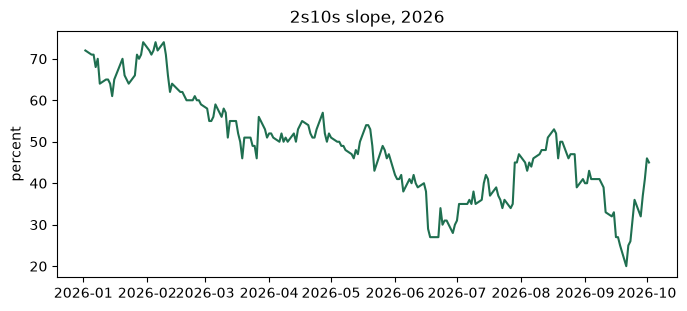

In [16]:
import matplotlib.pyplot as plt

# the chart code: written for this course in the style of an AI assistant's answer
def plot_2s10s(curve):
    """Line chart of the 2s10s slope in bp (10 Yr less 2 Yr, times 100), with its unit on the y axis."""
    slope = (curve["10 Yr"] - curve["2 Yr"]) * 100
    fig, ax = plt.subplots(figsize=(8, 3.2))
    ax.plot(slope.index, slope.to_numpy(), color="#1f6f50")
    ax.set_title("2s10s slope, 2026")
    ax.set_ylabel("percent")
    return fig, ax

fig, ax = plot_2s10s(curve.loc["2026"])

Q. Check the chart against the numbers behind it: does the axis name the unit of the data, and is the line exactly your `slope_bp`?

In [17]:
def check_chart(ax, series, unit):
    """Stop unless the y axis label names the unit, and the first line holds exactly the series' values."""
    assert unit in ax.get_ylabel(), f"the y axis says {ax.get_ylabel()!r}, but the data is in {unit}"
    plotted = ax.lines[0].get_ydata()
    assert len(plotted) == len(series), "the line has a different number of points"
    assert (abs(plotted - series.to_numpy()) <= 1e-9).all(), "the line is not the series"

In [18]:
# the numbers behind the chart, from your own function
slope_2026 = md.slope_bp(curve.loc["2026"], "2 Yr", "10 Yr")
check_chart(ax, slope_2026, "bp")

AssertionError: the y axis says 'percent', but the data is in bp

* The line is right and the label is wrong: the data is in bp and the axis says percent. A reader would take the last point, 45, as 45 percent. The code ran, and a chart cannot raise an error for a wrong word.
* The check reads the chart object itself: `ax.get_ylabel()` for the label, `ax.lines[0].get_ydata()` for the numbers drawn. That turns "looks right" into a test.

Q. Fix the label and check again.

checked: the axis names bp, and the last point is 45.0 bp on 2026-10-02


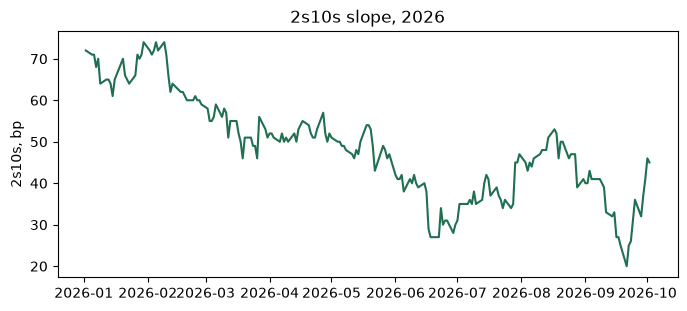

In [19]:
ax.set_ylabel("2s10s, bp")
check_chart(ax, slope_2026, "bp")
last = ax.lines[0].get_ydata()[-1]
print(f"checked: the axis names bp, and the last point is {last:.1f} bp on {slope_2026.index[-1].date()}")
fig

## 13.4 Testing an Assistant's Bond Code against Your Own `bondmath`

Course 2 gave you `bondmath`, 24 functions tested against Excel. That makes it the reference for any bond code an assistant writes. The bonds are Course 2's four running bonds (synthetic issuers), settled on **2026-11-30**, between coupons, at their issue yields: the settlement Course 2 used for DV01 on its week 2 day 4.

Q. Type in the four bonds, and read Excel's DV01 for each from Course 2's reference file.

In [20]:
from datetime import date

# Course 2's four running bonds: synthetic issuers and CUSIPs, semiannual, 30/360, settled between coupons
bonds = pd.DataFrame({
    "cusip": ["99001BZA7", "99002CZA4", "99003DZA1", "99004EZA8"],
    "issuer": ["Quorvane Energy", "Dunmarrow Rail", "Pellwick Paper", "Halvering Foods"],
    "coupon_pct": [5.25, 6.125, 4.75, 7.50],
    "maturity": [date(2031, 9, 30), date(2033, 9, 30), date(2029, 9, 30), date(2036, 9, 30)],
    "yield_pct": [5.40, 6.125, 4.60, 7.70],
})
settlement = date(2026, 11, 30)

# Excel's DV01 per 100 for each bond at that settlement: =MDURATION(...)*(PRICE(...)+accrued)/10000
excel = pd.read_csv("bondmath_excel_reference.csv", float_precision="round_trip")
bonds["excel_dv01"] = excel[excel["group"] == "week2"].set_index("case_id").loc[bonds["cusip"], "dv01"].to_numpy()
bonds[["issuer", "coupon_pct", "maturity", "yield_pct", "excel_dv01"]]

,issuer,coupon_pct,maturity,yield_pct,excel_dv01
0,Quorvane Energy,5.250,2031-09-30,5.400,0.041903
1,Dunmarrow Rail,6.125,2033-09-30,6.125,0.055175
2,Pellwick Paper,4.750,2029-09-30,4.600,0.026359
3,Halvering Foods,7.500,2036-09-30,7.700,0.067511


**The assistant's DV01**, asked for with the docstring of your own `bondmath.dv01`. Written for this course in the style of an AI assistant's answer.

In [21]:
# written for this course in the style of an AI assistant's answer
def assistant_dv01(settlement, maturity, coupon_pct, yield_pct):
    """DV01: price points per 100 of face for a 1 basis point fall in yield, positive for a long position.

    Units: coupon_pct and yield_pct in percent a year; the result is in price points per 100 of face per bp.
    Convention: modified duration x dirty price x 0.0001, semiannual, 30/360.
    """
    # modified duration times the price, for one basis point (0.0001 as a decimal)
    duration = bondmath.modified_duration(settlement, maturity, coupon_pct, yield_pct)
    return duration * bondmath.price(settlement, maturity, coupon_pct, yield_pct) * 0.0001

Q. Predict, then test: does it equal your `bondmath.dv01` and Excel, to 1e-8 per 100?

In [22]:
for bond in bonds.itertuples():
    mine = bondmath.dv01(settlement, bond.maturity, bond.coupon_pct, bond.yield_pct)
    theirs = assistant_dv01(settlement, bond.maturity, bond.coupon_pct, bond.yield_pct)
    assert abs(mine - bond.excel_dv01) < 1e-8, "your bondmath disagrees with Excel"
    assert abs(theirs - bond.excel_dv01) < 1e-8, f"{bond.issuer}: {theirs:.6f} against Excel's {bond.excel_dv01:.6f} per 100"

AssertionError: Quorvane Energy: 0.041537 against Excel's 0.041903 per 100

Q. How far off is each bond, and what explains the gap?

In [23]:
bonds["assistant_dv01"] = [assistant_dv01(settlement, b.maturity, b.coupon_pct, b.yield_pct) for b in bonds.itertuples()]
bonds["accrued"] = [bondmath.accrued_interest(settlement, b.maturity, b.coupon_pct) for b in bonds.itertuples()]
# the gap as a share of the right answer, in percent
bonds["gap_pct"] = (bonds["excel_dv01"] - bonds["assistant_dv01"]) / bonds["excel_dv01"] * 100
bonds[["issuer", "excel_dv01", "assistant_dv01", "accrued", "gap_pct"]]

,issuer,excel_dv01,assistant_dv01,accrued,gap_pct
0,Quorvane Energy,0.041903,0.041537,0.875000,0.872935
1,Dunmarrow Rail,0.055175,0.054618,1.020833,1.010620
2,Pellwick Paper,0.026359,0.026152,0.791667,0.782435
3,Halvering Foods,0.067511,0.066666,1.250000,1.251596


* Every bond is low, by 0.78 to 1.25 percent. The docstring says **dirty** price; the code calls `bondmath.price`, the **clean** price. The gap is modified duration times the accrued interest times 0.0001, so it grows with the accrued. Quorvane's DV01 is 0.041903 per 100 and the answer gives 0.041537.
* A number 1 percent off looks right. Only a test against a reference you trust shows it.

Q. Would a test on the issue date, 2026-09-30, have caught it?

In [24]:
issue_date = date(2026, 9, 30)
# on a coupon date nothing has accrued, so the clean and the dirty price are the same number
same = [assistant_dv01(issue_date, b.maturity, b.coupon_pct, b.yield_pct) == bondmath.dv01(issue_date, b.maturity, b.coupon_pct, b.yield_pct)
        for b in bonds.itertuples()]
print(f"equal on the issue date, all four bonds: {all(same)}")

equal on the issue date, all four bonds: True


* No: on a coupon date the bug is invisible. Course 2 settled its week 2 bonds between coupons for exactly this reason. Choose test cases where the mistake would show: a settlement with accrued interest, a month ending on a weekend, the start of a series.
* The fix is one word, `dirty_price` for `price`, or better, use `bondmath.dv01`, which you already tested.

## 13.5 Debugging with an Assistant

An assistant is useful for an error you do not understand. What you paste decides whether that is safe.

| Paste | Never paste |
| --- | --- |
| The line of code that failed | An API key, a password, a token |
| The last lines of the traceback: the error's type and message | A URL or an error message that holds a key |
| A few rows of public or synthetic data that show the problem | Client names, positions, trades, anything from an employer |
| Your Python and pandas versions | A full path with your user name in it |

Q. Is day 1's error message safe to paste?

In [25]:
try:
    md.get_secret("NO_SUCH_SECRET", env_file=work / ".env")
except RuntimeError as error:
    day1_message = f"RuntimeError: {error}"
print(day1_message)

RuntimeError: Secret NO_SUCH_SECRET not found. Looked in: the environment variable NO_SUCH_SECRET, Colab's Secrets panel, and the file .env given as env_file.


* Yes. Day 1 wrote `get_secret` so its message names the secret and the places looked, and holds no value and no folder. It can go into a chat as it is.

Day 2 showed a message that is not safe: `requests`' `raise_for_status()` puts the whole request URL in its message, key included. This is what it says for a FRED error, with the course's fake key (the text was made by the course, from `requests` itself, with no request sent):

```
400 Client Error: Bad Request for url: https://api.stlouisfed.org/fred/series/observations?series_id=DGS10&api_key=fakefakefakefakefakefakefakefake&file_type=json
```

Q. Write `redact`, which replaces the value of any `api_key=` with `***` and your home folder with `~`, and a check, `safe_to_paste`, that stops when a key or your home folder is still there.

In [26]:
import re

# the message raise_for_status() gives for a FRED error, with the course's fake key
http_message = "400 Client Error: Bad Request for url: https://api.stlouisfed.org/fred/series/observations?series_id=DGS10&api_key=fakefakefakefakefakefakefakefake&file_type=json"

# the name of the URL parameter that carries a FRED key
KEY_PARAM = "api_key"

def redact(text):
    """Text with the value of every api_key parameter replaced by *** and your home folder by ~."""
    text = re.sub(KEY_PARAM + r"=[^&\s]+", KEY_PARAM + "=***", text)
    return text.replace(str(Path.home()), "~")

def safe_to_paste(text):
    """Stop if the text holds an api_key value, a 32-character token that could be a key, or your home folder."""
    assert not re.search(KEY_PARAM + r"=(?!\*\*\*)", text), "an api_key value"
    assert not re.search(r"\b[a-z0-9]{32}\b", text), "a 32-character token that could be a key"
    assert str(Path.home()) not in text, "your home folder, which holds your user name"

print(redact(http_message))
safe_to_paste(redact(http_message))
print("the redacted message is safe to paste")

400 Client Error: Bad Request for url: https://api.stlouisfed.org/fred/series/observations?series_id=DGS10&api_key=***&file_type=json
the redacted message is safe to paste


Q. And the message as it came?

In [27]:
safe_to_paste(http_message)

AssertionError: an api_key value

* The check stops on the original. Run your text through it before it leaves your machine. A rotated key is the fix for a key that has already gone (day 1); this check is how it does not go.

Q. A real debugging question: `change_bp` refuses a series. Put together what you would paste: the line, the error, five rows of synthetic data, and the question.

In [28]:
# five days of the synthetic high yield spread, in bp, with one day missing
gappy = spreads["hy_spread_bp"].loc["2026-09-28":"2026-10-02"].copy()
gappy.loc["2026-09-30"] = float("nan")
try:
    md.change_bp(gappy, percent_units=False)
except ValueError as error:
    error_line = f"ValueError: {error}"

paste = "\n".join([
    f"This line raises an error (Python {sys.version_info.major}.{sys.version_info.minor}, pandas {pd.__version__}):",
    "md.change_bp(gappy, percent_units=False)",
    redact(error_line),
    "The input, five rows of synthetic data, spreads in bp:",
    gappy.to_csv().strip(),
    "Why does it refuse the series, and how should a missing day be handled if it may never be filled?",
])
safe_to_paste(paste)
print(paste)

This line raises an error (Python 3.13, pandas 3.0.6):
md.change_bp(gappy, percent_units=False)
ValueError: series has 1 missing values; drop them first with .dropna()
The input, five rows of synthetic data, spreads in bp:
date,hy_spread_bp
2026-09-28,320.0
2026-09-29,331.1
2026-09-30,
2026-10-01,330.0
2026-10-02,328.7
Why does it refuse the series, and how should a missing day be handled if it may never be filled?


* Everything an assistant needs and nothing it must not have: the line, the message `series has 1 missing values; drop them first with .dropna()`, five rows of invented data showing the gap, and the question. The message is your own function's (day 6), so it already says what to do.
* Notice the question carries the rule ("a missing day may never be filled"). Leave it out and a common answer is to fill the gap, which this course forbids before a change is computed. The prompt is a spec here too.

## 13.6 A Package That Does Not Exist

An assistant can name a package that has never existed, with a plausible name, an import line, and functions to call. This reply was written for this course in the style of an AI assistant's answer:

> For DV01 straight from FRED data, use the `fredbond-tools` package. Install it with pip, then:
>
> ```python
> import fredbond_tools as fbt
> fbt.curve_dv01(series_id="DGS10", maturity_years=5)
> ```

The name **fredbond-tools** is invented for this course. There was no project of that name on PyPI, the Python Package Index, when it was checked on 2026-10-04.

Q. Try the import line from the reply.

In [29]:
import fredbond_tools

ModuleNotFoundError: No module named 'fredbond_tools'

* `ModuleNotFoundError`: nothing of that name is installed. The tempting next step is to install it. **Do not.** Check the name first.

Why installing an invented name is dangerous: anyone can register an unused name on PyPI. If assistants suggest a name that does not exist, someone can register it and put their own code in it. `pip install` then downloads and runs code written by whoever owns the name, and importing the package runs it again, with the same access to your files that you have. A name that does not exist today can exist tomorrow, owned by a stranger.

How to check a name before installing anything (PowerShell, shown as text; the notebook never runs it):

```powershell
# 1. look the name up on PyPI in your browser: https://pypi.org/project/<name>/
# 2. ask pip which versions PyPI has. This installs nothing.
python -m pip index versions fredbond-tools
python -m pip index versions requests
```

On 2026-10-04 the first printed `ERROR: No matching distribution found for fredbond-tools` and the second began `requests (2.34.2)`. A real project's PyPI page also shows who maintains it, its release history, and a link to its source. A name with no page, no history, or a page created last week is a reason to stop. At work, your firm decides what may be installed on its machines.

Q. Check without importing: can Python find `fredbond_tools`, and `pandas`?

In [30]:
import importlib.util

# find_spec looks for a module and runs none of its code; None means Python cannot import it
for name in ["fredbond_tools", "pandas"]:
    print(f"{name}: {'installed' if importlib.util.find_spec(name) is not None else 'not installed'}")

fredbond_tools: not installed
pandas: installed


An assistant can also invent an **argument**: a real function called with an option it never had, or one removed years ago. Python stops with a `TypeError` naming the argument, and `inspect.signature` lists the real ones.

Q. Which arguments does `pd.Series.resample` take?

In [31]:
import inspect

params = [name for name in inspect.signature(pd.Series.resample).parameters if name != "self"]
print(f"resample takes: {params}")
print(f"'how' among them: {'how' in params}")

resample takes: ['rule', 'closed', 'label', 'convention', 'on', 'level', 'origin', 'offset', 'group_keys']
'how' among them: False


* Keep that cell in mind for the AI check at the end of the exercises.

## 13.7 JSON Replies and `parse_json_reply`

Day 2 met JSON as the format of FRED's answers. It is also the format AI tools speak when a program, not a person, reads the reply: ask for "one JSON object with these fields and nothing else" and the answer can be read by `json.loads`. Can be: replies often arrive with a friendly sentence in front, or without a field you asked for. So the reply is checked before any field is used.

The prompt for this section asked an assistant to state the definition behind a number, the 63-row volatility of the 10 Yr's daily changes, as JSON with the fields `series_id`, `units`, `window_rows`, `min_periods`, `includes_today`.

Q. Add `parse_json_reply` to `marketdata.py`, docstring first. Read the docstring before you run the cell.

In [32]:
%%writefile -a marketdata.py


import json  # an assistant's JSON reply, from day 13


def parse_json_reply(text: str, required: list[str]) -> dict:
    """Read an AI assistant's reply that was asked to answer in JSON, and check it has the fields asked for.

    Units: none. Convention: the whole reply must be one JSON object (json.loads); extra fields are kept.
    Raises ValueError if the text is not JSON, is JSON but not an object, or lacks any field in `required`
    (the message names every missing field).
    """
    # parse the reply; a reply with prose around the JSON fails here
    try:
        reply = json.loads(text)
    except json.JSONDecodeError as error:
        raise ValueError(f"the reply is not valid JSON: {error.msg} at line {error.lineno}, column {error.colno}") from error
    # an object, not a list or a bare number
    if not isinstance(reply, dict):
        raise ValueError(f"the reply is JSON but not an object: it is a {type(reply).__name__}")
    # every field asked for
    missing = [field for field in required if field not in reply]
    if missing:
        raise ValueError(f"the reply is missing {', '.join(missing)}")
    return reply

Appending to marketdata.py


* `json.loads` reads the whole text or raises `json.JSONDecodeError`, which the function turns into a `ValueError` saying where reading stopped. A reply that is valid JSON but a list or a number is refused too. Every missing field is named in one message.
* `import json` sits above the function, where today's code starts. In your own file you may move it to the top with the other imports.

Q. Add the three tests and run them.

In [33]:
%%writefile -a test_marketdata.py


def test_parse_json_reply_fields():
    text = '{"series_id": "DGS10", "units": "percent", "window_rows": 252, "note": "extra fields are kept"}'
    reply = md.parse_json_reply(text, ["series_id", "units", "window_rows"])
    assert reply["window_rows"] == 252 and reply["note"] == "extra fields are kept"


def test_parse_json_reply_missing_field_raises():
    with pytest.raises(ValueError, match="units, window_rows"):
        md.parse_json_reply('{"series_id": "DGS10"}', ["series_id", "units", "window_rows"])


def test_parse_json_reply_not_json_raises():
    # prose around the JSON, as assistants often add
    with pytest.raises(ValueError):
        md.parse_json_reply('Sure! Here is the JSON: {"series_id": "DGS10"}', ["series_id"])
    with pytest.raises(ValueError):
        md.parse_json_reply('["DGS10", "DGS2"]', ["series_id"])

Appending to test_marketdata.py


In [34]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_marketdata.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

...................................................                      [100%]
51 passed in 1.06s



* `51 passed`: the 3 new tests and every earlier one.

Q. Reload the module, and parse three replies (written for this course in the style of an AI assistant's answer): a clean one, one with a sentence in front, and one missing a field.

In [35]:
importlib.reload(md)

FIELDS = ['series_id', 'units', 'window_rows', 'min_periods', 'includes_today']
replies = {
    "clean": '{"series_id": "DGS10", "units": "bp", "window_rows": 63, "min_periods": 63, "includes_today": true}',
    "with a sentence": 'Sure! Here is the definition you asked for:\n{"series_id": "DGS10", "units": "bp", "window_rows": 63, "min_periods": 63, "includes_today": true}',
    "missing a field": '{"series_id": "DGS10", "units": "bp", "window_rows": 63, "includes_today": true}',
}
for label, text in replies.items():
    try:
        reply = md.parse_json_reply(text, FIELDS)
        print(f"{label}: ok, {len(reply)} fields")
    except ValueError as error:
        print(f"{label}: ValueError: {error}")

clean: ok, 5 fields
with a sentence: ValueError: the reply is not valid JSON: Expecting value at line 1, column 1
missing a field: ValueError: the reply is missing min_periods


* The clean reply passes. The sentence in front stops `json.loads` at its first character (`the reply is not valid JSON: Expecting value at line 1, column 1`), and the missing field is named. In both cases the right move is to ask again, not to guess.

Q. The shape is right. Is the content? Check the clean reply against the course's conventions.

In [36]:
reply = md.parse_json_reply(replies["clean"], FIELDS)
# JSON's true arrives as Python's True; numbers arrive as int or float
assert reply["units"] == "bp", "volatility of changes is in bp"
assert reply["min_periods"] == reply["window_rows"], "no partial windows"
assert reply["includes_today"] is True, "the window includes the current row"
print(f"{reply['series_id']}: {reply['window_rows']} rows, min_periods {reply['min_periods']}, units {reply['units']}")

DGS10: 63 rows, min_periods 63, units bp


* `parse_json_reply` checks the shape; your conventions check the content. Both are tests, and both run in your notebook, not in the assistant.

## Excel Side by Side

Assistants suggest formulas too. Asked for "the percent of the last 252 days at or below today's 10-year yield", a common suggestion is `PERCENTRANK.INC`. The course's measure is `COUNTIF` over `COUNT` (day 8). Tested in Excel 16.0 build 20430, 2026-10-04:

| Job | Python | Excel (tested) | Excel returns |
| --- | --- | --- | --- |
| Share at or below, the course's measure | `md.rolling_percentile_rank(curve["10 Yr"], 252)` | `=COUNTIF(B1:B252,"<="&B252)/COUNT(B1:B252)*100`, the 252 rows to 2026-10-02 | 99.60317460317461 |
| The assistant's suggestion, same window | none | `=PERCENTRANK.INC(B1:B252,B252)` | 0.996 |
| The ten-value probe set 5, 7, 7, 9, 11, 12, 3, 7, 10, 8, at 7 | | `=COUNTIF(A1:A10,"<="&7)/COUNT(A1:A10)` | 0.5 |
| The suggestion on the probe set | | `=PERCENTRANK.INC(A1:A10,7)` | 0.222 |
| DV01 of Quorvane, Course 2's formula | `bondmath.dv01(...)` | `=B4*(B1+B2)/10000` (B1 `PRICE`, B2 accrued, B4 `MDURATION`) | 0.04190266430092781 |
| The assistant's DV01 in Excel | `assistant_dv01(...)` | `=B4*B1/10000` | 0.0415368812533095 |

**`PERCENTRANK.INC` looks right on the last day.** On 2026-10-02 the course's measure gives 99.60 and `PERCENTRANK.INC` gives 0.996, which reads as 99.6 percent. The probe set shows the difference: 7 has 5 of 10 values at or below it, so `COUNTIF` gives 0.5, while `PERCENTRANK.INC` counts the values strictly below (2) over n - 1 (9) and cuts the result to three decimals, 0.222. Day 8 tested it as a lookalike. The reference file holds both columns for all 190 rows of 2026, so the suggestion can be tested the way any answer is.

**DV01 in cells.** The assistant's bug has an Excel twin: drop the accrued B2 from Course 2's `=B4*(B1+B2)/10000` and the cell becomes `=B4*B1/10000`, the clean-price DV01, 0.0415368812533095 against 0.04190266430092781.

Q. Over the 190 reference rows, how far is the suggestion from your function, and how far is `COUNTIF`?

In [37]:
# your percentile rank over the whole history (the 252-row windows reach back into 2025), kept on the 2026 rows
mine = md.rolling_percentile_rank(curve["10 Yr"], 252).loc[reference.index]
gap_countif = (mine - reference["pctrank252_10y"]).abs()
# PERCENTRANK.INC returns a fraction, so times 100 to compare in percent
gap_suggestion = (mine - reference["percentrank_inc252_10y"] * 100).abs()
print(f"COUNTIF/COUNT*100: largest gap {gap_countif.max():.1e} points over {len(reference)} rows")
print(f"PERCENTRANK.INC*100: differs on {(gap_suggestion > 1e-9).sum()} of {len(reference)} rows, by up to {gap_suggestion.max():.2f} points ({gap_suggestion.idxmax().date()})")

COUNTIF/COUNT*100: largest gap 0.0e+00 points over 190 rows
PERCENTRANK.INC*100: differs on 172 of 190 rows, by up to 5.02 points (2026-04-20)


* `COUNTIF` matches to the last digit. The suggestion differs on 172 of 190 rows, by up to 5.02 points on 2026-04-20. It answers a different question, which is the most common way a suggested formula goes wrong: it runs, returns a number in the right range, and measures something else.

## Save the Day with Git

First, commit today's module and tests. Then review a patch: assistants that edit code often answer with a **patch**, a text file that lists the lines to remove (`-`) and add (`+`). Git can check it, apply it, show it, and undo it.

In [38]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [39]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course3_13_h8zykdyb and nowhere else


Q. Commit the two files.

In [40]:
# choose the two files, commit, then show the history
!git -C "{work}" add marketdata.py test_marketdata.py
!git -C "{work}" commit -q -m "Add parse_json_reply and its tests" -m "An assistant asked for JSON is checked before any field of its reply is used."
!git -C "{work}" log --oneline

ba3e2a6 Add parse_json_reply and its tests


Q. The assistant's patch arrives. It changes `parse_json_reply` "so a reply with prose around it still parses". Written for this course in the style of an AI assistant's answer. Save it as `suggestion.patch`.

In [41]:
%%writefile suggestion.patch
--- a/marketdata.py
+++ b/marketdata.py
@@ -624,9 +624,10 @@
     Raises ValueError if the text is not JSON, is JSON but not an object, or lacks any field in `required`
     (the message names every missing field).
     """
-    # parse the reply; a reply with prose around the JSON fails here
+    # find the JSON object inside the reply, so a reply with prose around it still parses
+    start, end = text.find("{"), text.rfind("}")
     try:
-        reply = json.loads(text)
+        reply = json.loads(text[start:end + 1])
     except json.JSONDecodeError as error:
         raise ValueError(f"the reply is not valid JSON: {error.msg} at line {error.lineno}, column {error.colno}") from error
     # an object, not a list or a bare number

Writing suggestion.patch


Q. Will it apply cleanly? `git apply --check` tries it without changing anything and prints nothing when it would apply.

In [42]:
# check it, apply it, then read exactly what changed
!git -C "{work}" apply --check suggestion.patch
!git -C "{work}" apply suggestion.patch
!git -C "{work}" diff

diff --git a/marketdata.py b/marketdata.py
index 2f9a3ec..01174dd 100644
--- a/marketdata.py
+++ b/marketdata.py
@@ -624,9 +624,10 @@ def parse_json_reply(text: str, required: list[str]) -> dict:
     Raises ValueError if the text is not JSON, is JSON but not an object, or lacks any field in `required`
     (the message names every missing field).
     """
-    # parse the reply; a reply with prose around the JSON fails here
+    # find the JSON object inside the reply, so a reply with prose around it still parses
+    start, end = text.find("{"), text.rfind("}")
     try:
-        reply = json.loads(text)
+        reply = json.loads(text[start:end + 1])
     except json.JSONDecodeError as error:
         raise ValueError(f"the reply is not valid JSON: {error.msg} at line {error.lineno}, column {error.colno}") from error
     # an object, not a list or a bare number


* Two lines out, three in: the function now cuts the text from the first `{` to the last `}` before reading it. The diff is the review: read every `-` and `+` line before you run anything.

Q. Run the tests on the patched module.

In [43]:
# --tb=no prints which tests failed, without the long tracebacks
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_marketdata.py", "--tb=no"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

..................................................F                      [100%]
=========================== short test summary info ===========================
FAILED test_marketdata.py::test_parse_json_reply_not_json_raises - Failed: DID NOT RAISE ValueError
1 failed, 50 passed in 0.97s



* `test_parse_json_reply_not_json_raises` fails. The patch changed what the function promises: the docstring says the whole reply must be one JSON object, and the test, written from the docstring, holds it to that. Whether a reply with a sentence in front should be accepted is a decision. This course says no: a reply that ignored "nothing else" may have ignored other instructions too, and you want to know.

Q. Throw the patch away and confirm the module is back as committed.

In [44]:
# restore puts the file back as it is in the last commit
!git -C "{work}" restore marketdata.py
!git -C "{work}" status --short

?? __pycache__/
?? bondmath.py
?? bondmath_excel_reference.csv
?? course3_excel_reference.csv
?? course3_fred_format_dgs10.json
?? course3_synthetic_spreads.csv
?? holdings.csv
?? ratings.csv
?? suggestion.patch
?? trade_blotter.csv
?? treasury_par_yields.csv


In [45]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_marketdata.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

...................................................                      [100%]
51 passed in 0.96s



* `marketdata.py` no longer appears in the status: it matches the commit. `suggestion.patch`, `bondmath.py`, the data files, and `__pycache__/` are `??`, untracked, as they should be. `51 passed` again.

## Bring It Home

Add today's function to your own `marketdata.py`. Open a PowerShell terminal in VS Code, with the course's `.venv` active.

**Step 1.** Go to your folder and open the two files.

```powershell
Set-Location "$HOME\projects\my_bondmath"
code marketdata.py
code test_marketdata.py
```

Paste the code of the `%%writefile -a marketdata.py` cell of section 13.7, without its first line, at the end of `marketdata.py`, and the code of the `%%writefile -a test_marketdata.py` cell at the end of `test_marketdata.py`. Save both.

**Step 2.** Run the tests, read the change, and commit.

```powershell
python -m pytest -q test_marketdata.py
git diff --stat
git add marketdata.py test_marketdata.py
git commit -m "Add parse_json_reply and its tests" -m "An assistant asked for JSON is checked before any field of its reply is used."
```

The last line of pytest reads `51 passed`, with the time.

**Two habits to take with you.** Before you paste anything into an assistant, run it through a check like `safe_to_paste`, and keep your firm's policy in front of you. Before you install anything an assistant names, look the name up on PyPI.

## You Can Now

* Write a prompt as a specification: the docstring, the conventions that apply, and a test.
* Review an assistant's pandas code by running it against your own functions and Excel's reference values, at the edges as well as the middle.
* Check a chart against the numbers behind it by reading its labels and lines.
* Test an assistant's bond code against your own `bondmath`, on cases where a mistake would show.
* Debug with an assistant without pasting a key, a URL with a key, firm data, or your user name.
* Spot a package or an argument that does not exist, and check a name on PyPI before installing anything.
* Ask for JSON, and check the reply's shape with `parse_json_reply` and its content with your conventions.
* Review a patch with `git apply --check`, `git diff`, the tests, and `git restore`.

Tomorrow, day 14, puts the course together: the daily market snapshot, built by `snapshot_tables` and written to HTML and Excel for any date.

## Exercises

Every assistant answer below was written for this course in the style of an AI assistant's answer. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the data and defines `check`, a small function that marks your answers.

In [46]:
# the Treasury curve in percent and the synthetic spreads in bp
curve = pd.read_csv("treasury_par_yields.csv", parse_dates=["date"], index_col="date", float_precision="round_trip")
spreads = pd.read_csv("course3_synthetic_spreads.csv", parse_dates=["date"], index_col="date", float_precision="round_trip")
FIELDS = ['series_id', 'units', 'window_rows', 'min_periods', 'includes_today']


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

The prompt asked for a function with the docstring of your own `md.align` (day 3), which says: "Nothing is filled." This came back:

In [47]:
# written for this course in the style of an AI assistant's answer
def assistant_align(series, how="inner"):
    """Put several dated series side by side, one column each, joined on date. Nothing is filled."""
    # join every series on date
    frame = pd.concat(series, axis=1, join=how)
    # fill the gaps from the day before, so every column has a value on every date
    return frame.ffill()

Q. The September 2026 5 Yr and a copy of the synthetic high yield spread with one day missing are below. Run both `md.align` and `assistant_align` on them with `how="outer"`. Store in **ex1_filled** the number of values the assistant's answer holds where `md.align` leaves `NaN`, and in **ex1_date** that date as text, `"YYYY-MM-DD"`.

In [48]:
five_sep = curve["5 Yr"].loc["2026-09"]
# a vendor file missing one day
hy_sep = spreads["hy_spread_bp"].loc["2026-09"].drop(pd.Timestamp("2026-09-15"))
pair = {"5 Yr": five_sep, "hy_spread_bp": hy_sep}

In [49]:
ex1_filled = ...
ex1_date = ...

In [50]:
check("Exercise 1 values filled", ex1_filled, 1)
check("Exercise 1 the date", ex1_date, "2026-09-15")

Exercise 1 values filled: not attempted yet
Exercise 1 the date: not attempted yet


### Exercise 2

Q. A reply came back for the 21-row volatility of the 2 Yr, asked for with the same five fields as section 13.7 (`FIELDS`, defined above). Validate it with `md.parse_json_reply`, catch the `ValueError`, and store its message, as text, in **ex2_message**.

In [51]:
# written for this course in the style of an AI assistant's answer
ex2_reply = '{"series_id": "DGS2", "units": "bp", "window_rows": 21, "includes_today": true}'

In [52]:
ex2_message = ...

In [53]:
check("Exercise 2 the message", ex2_message, "the reply is missing min_periods")

Exercise 2 the message: not attempted yet


### Exercise 3

Q. Add a function to your module. `is_installed(package)` returns `True` when Python can import `package`, using `importlib.util.find_spec`, which looks for a module without running any of its code. Write the docstring first: say that `package` is the import name (`fredbond_tools`), not the name pip uses (`fredbond-tools`), and make it raise `ValueError` for an empty name or one with a hyphen. Add a test, `test_is_installed`, that checks `"json"` is installed, `"fredbond_tools"` is not, and the `ValueError`. Run pytest, reload the module, and store `[md.is_installed("pandas"), md.is_installed("fredbond_tools")]` in **ex3_answers**.

Write the function in the cell that starts with `%%writefile -a marketdata.py` and the test in the one that starts with `%%writefile -a test_marketdata.py`, and run each of those cells once.

In [54]:
%%writefile -a marketdata.py


# Exercise 3: write is_installed(package) below this line

Appending to marketdata.py


In [55]:
%%writefile -a test_marketdata.py


# Exercise 3: write test_is_installed() below this line

Appending to test_marketdata.py


In [56]:
# run pytest, reload the module, then call your function
ex3_answers = ...

In [57]:
check("Exercise 3 pandas, then the invented package", ex3_answers, [True, False])

Exercise 3 pandas, then the invented package: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for month-end levels, and you give it the docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
The last observation of each calendar month, labelled by the date of that observation.

    Units: unchanged (a yield in percent stays in percent). Convention: the market's days are the rows of
    the series; each month's row is the last row the series has in that month, kept with its own date, so
    January 2026 is labelled 2026-01-30 (the 31st was a Saturday) and September 2026 is 2026-09-30.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. Unlike the other AI checks in this course, this one does not run quietly: it uses an argument that does not exist.

In [58]:
# written for this course in the style of an AI assistant's answer. It contains one bug.
def month_end_levels(series):
    """The last observation of each calendar month, labelled by the date of that observation.

    Units: unchanged (a yield in percent stays in percent). Convention: the market's days are the rows of
    the series; each month's row is the last row the series has in that month, kept with its own date, so
    January 2026 is labelled 2026-01-30 (the 31st was a Saturday) and September 2026 is 2026-09-30.
    """
    # resample to calendar months and keep the last value of each one
    return series.resample("ME", how="last")

Q. Before you run the next cell: will it run at all? Look at the arguments of the one call in the function.

In [59]:
# the test, written from the docstring before the code is trusted
result = month_end_levels(curve["10 Yr"].loc["2026"])
assert result.index[0] == pd.Timestamp("2026-01-30"), f"January is labelled {result.index[0].date()}"
assert result.loc["2026-09-30"] == 5.29, "September's level is not 5.29 percent"
print(f"{len(result)} months, January labelled {result.index[0].date()}, September {result.loc['2026-09-30']} percent")

TypeError: NDFrame.resample() got an unexpected keyword argument 'how'

Q. Read the error's last line. Find the real method with `inspect.signature`, as in section 13.6, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Watch the January label. Then store the January label as text, `str(month_end_levels(curve["10 Yr"].loc["2026"]).index[0].date())`, in **ex4_january**, and the September level in **ex4_september**.

In [60]:
# fix the function above and run the test again, then store the two answers
ex4_january = ...
ex4_september = ...

In [61]:
check("Exercise 4 the January label", ex4_january, "2026-01-30")
check("Exercise 4 the September level", ex4_september, 5.29)

Exercise 4 the January label: not attempted yet
Exercise 4 the September level: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```